# Phân loại bình luận tiếng Việt cho SafeView

**CS114 • SVM, Logistic Regression, PhoBERT và BamiBERT trên ViHSD**

BamiBERT được chọn trước để triển khai cho extension theo yêu cầu người dùng.
`validation_best_family` ghi mô hình đứng đầu dev riêng; không mặc định BamiBERT thắng.
ComplementNB còn ở cấu hình phụ `configs/traditional.yaml` nếu rubric yêu cầu ba
thuật toán truyền thống.

`RUN_ID` đặt tên đợt mới (ví dụ `vihsd-003`); `REFERENCE_RUN_ID` chỉ run lịch sử
để đối chiếu (`vihsd-002`). Dùng các cờ train/resume/test ở cell 1. Phần thực nghiệm
mất cân bằng tạo cặp baseline không/có trọng số và chỉ train thêm Transformer weighted
loss. Không train/test lại run lịch sử và không chọn checkpoint hoặc threshold bằng test.


## 1. Thiết lập Colab hoặc đọc kết quả cục bộ

**Colab:** chọn runtime GPU, đặt `RUN_SETUP=True` để clone repo và cài dependencies.
Chọn `REPO_REF` có chứa mã mới: file notebook không tự push các thay đổi cục bộ lên GitHub.
Checkout Colab đã tồn tại không tự fetch/pull; `main` trong runtime có thể vẫn là bản cũ.
Cell **Đồng bộ source/config** phía sau mang theo bản source/config đã kiểm tra,
cập nhật phiên bản cũ đã biết và bỏ cache module trước cell import. Chỉ cần restart kernel
nếu đã đổi dependencies; cell đồng bộ không tự cài/nâng thư viện.
**Colab extension trong VS Code:** kernel vẫn chạy trên máy chủ Colab; thư mục và đăng nhập
GitHub trên máy bạn không tự chuyển sang runtime. Repo private cần `REPO_PRIVATE=True`.
Khi clone lần đầu, nhập GitHub fine-grained token ở ô nhập ẩn, chỉ cấp repo này và quyền
**Contents: Read-only**. Không dán token vào mã notebook hoặc URL; token chỉ được truyền
cho tiến trình Git, không lưu vào notebook hay remote. Repo public đặt `REPO_PRIVATE=False`.
Nếu cần lưu qua các phiên, đặt `MOUNT_DRIVE=True` và `RUN_ROOT_OVERRIDE` thành
`/content/drive/MyDrive/cs114-safeview`. Checkpoint trong `/content` có thể mất khi ngắt runtime.
Lưu mọi run của cùng nghiên cứu trong cùng output root để giữ dấu vết test.

Chọn `RUN_ID` mới trước khi train. Sau gián đoạn, giữ cùng ID/dataset SHA/config/source/runtime,
đặt `RUN_TRAINING=True` và `RESUME_TRAINING=True`; không tạo run mới để bỏ qua bước khóa/test.
Trong chế độ thực nghiệm bổ sung, có thể bật train/test/bundle cùng lúc để Run All
chạy tuần tự; cấu hình và quyết định validation được khóa tự động trước test. Chế độ
workflow gốc (`IMBALANCE_STUDY=False`) vẫn dùng các bước riêng như hướng dẫn cũ.
Các thay đổi cài package có thể cần restart kernel.

**Cục bộ:** cài `python -m pip install -e '.[dev,hub,serve,transformers]'` trước khi mở notebook.
`RUN_SETUP=False` không cài dependencies hoặc truy cập mạng.


In [2]:
from pathlib import Path
import os
import sys
import subprocess

REPO_URL = "https://github.com/andrewthongle/cs114-ml-project.git"
REPO_REF = "main"  # nhánh/tag/SHA chứa phiên bản mã muốn chạy
REPO_PRIVATE = True  # nhập token qua ô ẩn khi clone; repo public đặt False
COLAB_REPO = Path("/content/cs114-ml-project")
RUN_SETUP = True
MOUNT_DRIVE = True
RUN_LOAD_DATA = True
RUN_EDA = True
RUN_TRAINING = True
RESUME_TRAINING = False
RUN_FINAL_TEST = True
RUN_PREPARE_BUNDLE = True  # chỉ đóng gói local; notebook không publish

RUN_ROOT_OVERRIDE = "/content/drive/MyDrive/cs114-safeview"
RUN_ID = "vihsd-003"
DATA_REVISION = os.getenv("SAFEVIEW_DATA_REVISION", "main")
DATA_CACHE_DIR = None  # ví dụ Path("/content/drive/MyDrive/cs114-vihsd-cache")
CONFIG_NAME = "experiments.yaml"

# Script execute_notebook.py luôn bật chế độ chỉ đọc, kể cả notebook đã sửa cờ.
if os.getenv("SAFEVIEW_NOTEBOOK_READ_ONLY") == "1":
    RUN_SETUP = MOUNT_DRIVE = RUN_LOAD_DATA = RUN_EDA = False
    RUN_TRAINING = RESUME_TRAINING = RUN_FINAL_TEST = RUN_PREPARE_BUNDLE = False


def run_git(*args, authenticate=False):
    # Thu stderr để lỗi Git hiện ngay trong output notebook của VS Code.
    git_env = os.environ.copy()
    git_env["GIT_TERMINAL_PROMPT"] = "0"
    token = encoded = secret = ""
    try:
        if authenticate:
            import base64
            import getpass
            import warnings
            from urllib.parse import urlsplit

            url = urlsplit(REPO_URL)
            if url.scheme != "https" or url.netloc != "github.com":
                raise ValueError("Nhập token chỉ hỗ trợ REPO_URL dạng https://github.com/owner/repo.git")
            with warnings.catch_warnings():
                warnings.simplefilter("error", getpass.GetPassWarning)
                token = getpass.getpass("GitHub token (repo này, Contents: Read-only): ").strip()
            if not token:
                raise ValueError("Chưa nhập GitHub token; chạy lại cell để nhập.")
            encoded = base64.b64encode(("x-access-token:" + token).encode()).decode()
            # Git config qua env: không ghi token vào URL, argv hoặc .git/config.
            index = int(git_env.get("GIT_CONFIG_COUNT", "0"))
            git_env["GIT_CONFIG_COUNT"] = str(index + 1)
            git_env[f"GIT_CONFIG_KEY_{index}"] = f"http.{REPO_URL}.extraheader"
            git_env[f"GIT_CONFIG_VALUE_{index}"] = "AUTHORIZATION: basic " + encoded
        result = subprocess.run(["git", *args], env=git_env, text=True,
                                stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        output = result.stdout or ""
        for secret in (token, encoded):
            if secret:
                output = output.replace(secret, "[REDACTED]")
        result.stdout = output
    finally:
        git_env.clear()
        token = encoded = secret = ""
    if result.returncode:
        raise RuntimeError(
            f"Git thất bại (mã {result.returncode}):\n{output}\n"
            "Repo private: kiểm tra REPO_PRIVATE và quyền Contents: Read-only của token. "
            "Colab trong VS Code không dùng đăng nhập GitHub trên máy local."
        )
    return output.strip()


IN_COLAB = "google.colab" in sys.modules or Path("/content").is_dir()
if RUN_SETUP:
    assert IN_COLAB, "Setup này dành cho Colab; cục bộ cài package theo README."
    if not COLAB_REPO.exists():
        print(run_git("clone", "--no-checkout", REPO_URL, str(COLAB_REPO),
                      authenticate=REPO_PRIVATE))
        print(run_git("-C", str(COLAB_REPO), "checkout", REPO_REF))
    else:
        actual_remote = run_git("-C", str(COLAB_REPO), "remote", "get-url", "origin")
        assert actual_remote.rstrip("/") == REPO_URL.rstrip("/"), "Checkout khác REPO_URL; chọn COLAB_REPO mới."
        current_commit = run_git("-C", str(COLAB_REPO), "rev-parse", "HEAD")
        requested_commit = run_git("-C", str(COLAB_REPO), "rev-parse", "--verify", "--end-of-options",
                                   REPO_REF + "^{commit}")
        assert current_commit == requested_commit, "Checkout khác REPO_REF; tự kiểm tra/fetch/checkout trước khi chạy."
        print("Dùng checkout đang có:", current_commit)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e",
                    str(COLAB_REPO) + "[dev,hub,serve,transformers]"], check=True)
    os.chdir(COLAB_REPO)

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists() and (ROOT.parent / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Colab: bật RUN_SETUP; cục bộ: mở từ repo/notebooks."
# Editable .pth mới cài chưa được kernel hiện tại đọc; dùng source đúng checkout.
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
if MOUNT_DRIVE:
    assert IN_COLAB, "Google Drive mount chỉ dành cho Colab"
    from google.colab import drive
    drive.mount("/content/drive")
RUN_ROOT = Path(RUN_ROOT_OVERRIDE).expanduser().resolve() if RUN_ROOT_OVERRIDE else ROOT
print("Mã nguồn:", ROOT)
print("Output/checkpoints:", RUN_ROOT)
print("Mặc định: chỉ đọc kết quả. Dataset/train/test/publish không tự chạy.")

Mounted at /content/drive
Mã nguồn: /content/cs114-ml-project
Output/checkpoints: /content/drive/MyDrive/cs114-safeview
Mặc định: chỉ đọc kết quả. Dataset/train/test/publish không tự chạy.


### Run tham chiếu — dùng các cờ ở cell 1

Đặt `RUN_ID="vihsd-003"` ở cell 1 cho đợt mới. `REFERENCE_RUN_ID="vihsd-002"`
ở dưới chỉ kết quả cũ để đối chiếu. Không cần bộ cờ hành động riêng.

1. `RUN_TRAINING=True`: tự tạo kế hoạch, sau đó train các family được chọn.
2. Resume: giữ cùng `RUN_ID`, bật `RUN_TRAINING=True` và `RESUME_TRAINING=True`.
3. `RUN_FINAL_TEST=True`: khi train xong, tự khóa lựa chọn validation rồi đánh giá test.
4. `RUN_PREPARE_BUNDLE=True`: sau test, chuẩn bị bundle local của BamiBERT đã chọn.

Bật cả ba cờ rồi **Run All một lần** để chạy liên tục, không cần đổi cờ giữa các bước.
Nếu train lỗi hoặc thiếu một cấu hình, workflow dừng trước test. Run/test/bundle đã
hoàn tất được kiểm tra rồi dùng lại, không ghi đè. Không tự upload Hugging Face.

Các phần 4–9 hiển thị run tham chiếu; **phần 10 chạy và hiển thị đợt mới**.
Kết quả tổng hợp ở `results/studies/<RUN_ID>`; mỗi cấu hình có run/artifact riêng
với tiền tố `<RUN_ID>-<family>-<variant>`, không ghi đè `vihsd-002`.

PhoBERT/BamiBERT cũ được đọc từ báo cáo đã lưu, không train/test lại. SVM/LR lịch sử
đã dùng class weight balanced; đợt này fit cặp null/balanced cùng C và TF-IDF.
Study ghi rõ test đã được xem, một seed và khác biệt môi trường; không gọi kết quả là
tối ưu toàn cục hoặc một đánh giá trên test hoàn toàn chưa từng xem.

In [ ]:
IMBALANCE_STUDY = True
REFERENCE_RUN_ID = 'vihsd-002'
IMBALANCE_FAMILIES = ['svm', 'logistic_regression', 'phobert', 'bamibert']

_study_read_only = os.getenv("SAFEVIEW_NOTEBOOK_READ_ONLY") == "1"
STUDY_TRAIN = IMBALANCE_STUDY and RUN_TRAINING and not _study_read_only
STUDY_TEST = IMBALANCE_STUDY and RUN_FINAL_TEST and not _study_read_only
STUDY_BUNDLE = IMBALANCE_STUDY and RUN_PREPARE_BUNDLE and not _study_read_only
if (STUDY_TRAIN or STUDY_TEST or STUDY_BUNDLE) and (not RUN_ID or RUN_ID == REFERENCE_RUN_ID):
    raise ValueError("RUN_ID phải là đợt mới, khác REFERENCE_RUN_ID; ví dụ vihsd-003 và vihsd-002.")
STUDY = RUN_ROOT / "results/studies" / RUN_ID if RUN_ID else None
print("Chế độ:", "so sánh mất cân bằng" if IMBALANCE_STUDY else "workflow gốc")
print("Đợt mới:", RUN_ID, "| Run tham chiếu:", REFERENCE_RUN_ID)
print("Các bước đã bật:", [name for name, enabled in
      [("train", STUDY_TRAIN), ("test sau khóa validation", STUDY_TEST), ("bundle local", STUDY_BUNDLE)] if enabled])


### Đồng bộ source/config với notebook

Cell này mang theo source/config của bản notebook hiện tại để sửa tình trạng Colab
vẫn dùng checkout cũ. Khi `RUN_SETUP=True` trên Colab, cell kiểm tra toàn bộ checksum
rồi cập nhật các file phiên bản cũ đã biết và nạp lại module ở cell import tiếp theo.
Không cần push GitHub hoặc restart kernel cho bản sửa chỉ đổi Python/config này.
Cell 1, dữ liệu, checkpoint và kết quả của bạn được giữ nguyên.

Nếu source/config trên runtime có chỉnh sửa riêng hoặc dependencies khác, cell dừng
trước khi ghi file và trước khi train; không ghi đè phiên bản không nhận diện được.
Sau lỗi `unexpected keyword argument 'empty_text_policy'`, chạy từ cell này xuống
nếu cell setup đã hoàn tất. Mở lại notebook từ đĩa nếu VS Code còn hiển thị bản cũ.


In [ ]:
RUNTIME_PATHS = ('configs/experiments.yaml', 'configs/traditional.yaml', 'scripts/publish_hf.py', 'scripts/templates/hf_space/app.py', 'scripts/templates/hf_space/README.md', 'src/safeview_ml/__init__.py', 'src/safeview_ml/cli.py', 'src/safeview_ml/data.py', 'src/safeview_ml/evaluation.py', 'src/safeview_ml/features.py', 'src/safeview_ml/imbalance.py', 'src/safeview_ml/inference.py', 'src/safeview_ml/models.py', 'src/safeview_ml/policy.py', 'src/safeview_ml/preprocessing.py', 'src/safeview_ml/provenance.py', 'src/safeview_ml/remote_data.py', 'src/safeview_ml/training.py', 'src/safeview_ml/transformer_model.py')

def _decode_runtime_payload(payload, digest, *, allow_subset=False):
    """Validate carried bytes against the fixed source/config allowlist."""
    import base64
    import binascii
    import hashlib
    import io
    import json
    import re
    import zipfile

    def checksum(content):
        return hashlib.sha256(content).hexdigest()

    def valid_hash(value):
        return isinstance(value, str) and re.fullmatch(r"[0-9a-f]{64}", value) is not None

    if not isinstance(payload, str) or len(payload) > 4 * 1024 * 1024 or not valid_hash(digest):
        raise ValueError("Invalid notebook runtime payload or digest")
    try:
        packed = base64.b64decode(payload, validate=True)
    except (binascii.Error, ValueError) as exc:
        raise ValueError("Invalid notebook runtime payload encoding") from exc
    if checksum(packed) != digest:
        raise ValueError("Notebook runtime payload checksum mismatch")
    try:
        with zipfile.ZipFile(io.BytesIO(packed)) as archive:
            members = archive.infolist()
            names = [member.filename for member in members]
            allowed = set(RUNTIME_PATHS) | {"manifest.json"}
            if (len(names) != len(set(names)) or "manifest.json" not in names
                    or not set(names) <= allowed
                    or (not allow_subset and set(names) != allowed)):
                raise ValueError("Notebook runtime archive has unexpected or duplicate paths")
            if any(member.file_size > 1024 * 1024 for member in members):
                raise ValueError("Notebook runtime archive file exceeds its size limit")
            if sum(member.file_size for member in members) > 4 * 1024 * 1024:
                raise ValueError("Notebook runtime archive exceeds its size limit")
            contents = {name: archive.read(name) for name in names}
        manifest = json.loads(contents.pop("manifest.json"))
    except (zipfile.BadZipFile, RuntimeError, UnicodeDecodeError, json.JSONDecodeError) as exc:
        raise ValueError("Invalid notebook runtime archive or manifest") from exc
    if not isinstance(manifest, dict) or manifest.get("schema_version") != 1:
        raise ValueError("Unsupported notebook runtime manifest")
    entries = manifest.get("files")
    if not isinstance(entries, list) or not entries or len(entries) != len(contents):
        raise ValueError("Notebook runtime manifest has invalid file entries")
    if not valid_hash(manifest.get("pyproject_sha256")):
        raise ValueError("Notebook runtime manifest has invalid dependency checksum")
    records = {}
    for entry in entries:
        if not isinstance(entry, dict):
            raise ValueError("Notebook runtime manifest has invalid file entries")
        name = entry.get("path")
        if not isinstance(name, str) or name not in contents or name not in RUNTIME_PATHS or name in records:
            raise ValueError("Notebook runtime manifest has unexpected or duplicate paths")
        current, previous = entry.get("sha256"), entry.get("previous_sha256")
        if not valid_hash(current) or (previous is not None and not valid_hash(previous)):
            raise ValueError("Notebook runtime manifest has invalid file checksums")
        accepted = entry.get("accepted_sha256", [])
        if not isinstance(accepted, list) or any(not valid_hash(value) for value in accepted):
            raise ValueError("Notebook runtime manifest has invalid accepted checksums")
        if checksum(contents[name]) != current:
            raise ValueError(f"Notebook runtime file checksum mismatch: {name}")
        records[name] = entry
    return contents, manifest, records


def apply_runtime_payload(root, payload, digest, *, write=False):
    """Validate every file, then optionally replace known older files atomically.

    Return the paths that differ from the payload. Unknown local edits abort
    the entire operation before any file is changed. No modules are imported
    and no packages are installed by this helper.
    """
    import hashlib
    import os
    from pathlib import Path
    import tempfile

    def checksum(content):
        return hashlib.sha256(content).hexdigest()

    contents, manifest, records = _decode_runtime_payload(payload, digest)

    root = Path(root).resolve()

    def safe_target(name):
        target = root / name
        for path in (target, *target.parents):
            if path == root:
                break
            if path.is_symlink():
                raise ValueError(f"Notebook runtime refuses a symbolic-link path: {name}")
            if path != target and path.exists() and not path.is_dir():
                raise ValueError(f"Notebook runtime parent is not a directory: {name}")
        if target.exists() and not target.is_file():
            raise ValueError(f"Notebook runtime target is not a file: {name}")
        return target

    prerequisite = safe_target("pyproject.toml")
    required_hash = manifest.get("pyproject_sha256")
    if not prerequisite.is_file() or checksum(prerequisite.read_bytes()) != required_hash:
        raise ValueError("Runtime pyproject.toml differs from this notebook; synchronize the repository and dependencies first")

    changed, targets = [], {}
    for name in RUNTIME_PATHS:
        target = safe_target(name)
        targets[name] = target
        actual = checksum(target.read_bytes()) if target.exists() else None
        record = records[name]
        if actual == record["sha256"]:
            continue
        known_prior = {record.get("previous_sha256"), *record.get("accepted_sha256", [])}
        if actual is not None and actual not in known_prior:
            raise ValueError(f"Runtime file has unrecognized changes; preserve and review it before syncing: {name}")
        changed.append(name)
    if not write:
        return changed
    for name in changed:
        target = targets[name]
        target.parent.mkdir(parents=True, exist_ok=True)
        staged = None
        try:
            with tempfile.NamedTemporaryFile(dir=target.parent, prefix=".notebook-sync-", delete=False) as handle:
                staged = Path(handle.name)
                handle.write(contents[name])
            os.chmod(staged, target.stat().st_mode & 0o777 if target.exists() else 0o644)
            os.replace(staged, target)
        finally:
            if staged is not None:
                staged.unlink(missing_ok=True)
    return changed


# Source/config đi kèm notebook; không chứa dữ liệu, token hay cấu hình cell 1.
_runtime_payload = '...'
_runtime_digest = '38e814df06249c3245ef6ad6162d38053bf74e061750c639259016144d1a34e1'
if IN_COLAB and os.getenv("SAFEVIEW_NOTEBOOK_READ_ONLY") != "1":
    _runtime_updates = apply_runtime_payload(ROOT, _runtime_payload, _runtime_digest, write=RUN_SETUP)
    if _runtime_updates and not RUN_SETUP:
        raise RuntimeError("Runtime còn source/config cũ. Chạy cell setup với RUN_SETUP=True trước khi đồng bộ.")
    # Xóa module cũ khỏi cache; cell import phía sau nạp lại từ source đã kiểm tra.
    import importlib
    importlib.invalidate_caches()
    for _module_name in list(sys.modules):
        if _module_name == "safeview_ml" or _module_name.startswith("safeview_ml."):
            del sys.modules[_module_name]
    print("Source/config đã đồng bộ:", _runtime_updates or "đã đúng phiên bản")
    print("Chạy tiếp cell import; không cần restart nếu dependencies không đổi.")
else:
    print("Bỏ qua đồng bộ file: đang chạy local hoặc chế độ chỉ đọc.")
del _runtime_payload


In [ ]:
import json
import inspect
import pandas as pd
import yaml
from IPython.display import display, Markdown, Image
from safeview_ml.provenance import environment_metadata, read_json, sha256
from safeview_ml.data import export_eda, validate_training_data
from safeview_ml.remote_data import load_github_dataset
from safeview_ml.training import train_experiment, evaluate_locked

if "empty_text_policy" not in inspect.signature(validate_training_data).parameters:
    raise RuntimeError("Kernel đang dùng safeview_ml cũ. Chạy cell Đồng bộ source/config rồi chạy lại cell import này.")
CONFIG = yaml.safe_load((ROOT / "configs" / CONFIG_NAME).read_text(encoding="utf-8"))
env = environment_metadata()
display(pd.Series({"Python": env["python"], "Platform": env["platform"],
                   **env["versions"]}).to_frame("Phiên bản"))
display(CONFIG)
if RUN_TRAINING:
    import torch
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "không có CUDA")
    print("Colab Free không bảo đảm GPU/thời lượng; CPU fine-tune có thể chậm.")

# Nạp run được chỉ định trước khi tải để dùng lại chính xác revision dataset.
available_runs = sorted((RUN_ROOT / "results/runs").glob("*/selection.json"),
                        key=lambda path: (read_json(path).get("locked_at", ""), path.parent.name))
real_runs = [path for path in available_runs if read_json(path).get("synthetic") is False]
if RUN_ID is None and real_runs and not (RUN_TRAINING and not globals().get("IMBALANCE_STUDY", False)):
    RUN_ID = real_runs[-1].parent.name
VIEW_RUN_ID = REFERENCE_RUN_ID if globals().get("IMBALANCE_STUDY", False) else RUN_ID
RUN = RUN_ROOT / "results/runs" / VIEW_RUN_ID if VIEW_RUN_ID else None
run_metadata = read_json(RUN / "metadata.json") if RUN and (RUN / "metadata.json").exists() else None
if run_metadata and DATA_REVISION == "main":
    saved_manifest = run_metadata.get("dataset_manifest", {})
    if saved_manifest.get("source", "").startswith("https://github.com/"):
        DATA_REVISION = saved_manifest.get("revision") or DATA_REVISION
print("Đợt mới:", RUN_ID, "| Đang xem:", VIEW_RUN_ID, "| Dataset revision:", DATA_REVISION)

## 2. ViHSD trực tiếp từ GitHub và EDA

Nguồn: [ZIP chính thức của tác giả](https://github.com/sonlam1102/vihsd/blob/main/data/vihsd.zip).
`RUN_LOAD_DATA=True` lấy ZIP vào RAM/cache được cấu hình, không yêu cầu thư mục `data/raw`.
Giữ nguyên train/dev/test, ánh xạ `0=CLEAN`, `1=OFFENSIVE`, `2=HATE`; dev được gọi
là validation trong API. Branch/tag được phân giải sang commit SHA; dùng lại SHA đó
ở phiên sau. Dữ liệu tải được không tự cấp quyền tái phân phối; repo tác giả ghi dùng cho nghiên cứu.

Bật `RUN_EDA` cùng `RUN_LOAD_DATA`, đọc audit trước khi train. EDA chỉ tổng hợp test để
mô tả benchmark; test không dùng để lựa chọn preprocessing hoặc cấu hình. Near-duplicate audit
là sàng lọc giới hạn, không chứng minh đã tìm hết mẫu gần trùng.


,Giá trị
dataset,ViHSD
source,https://github.com/sonlam1102/vihsd
revision,826ef5efdda8f397e8b76b1ac26e05edda20ded6
fingerprint,889c4b1060ecd50850781d8501eaf6fc1b72d7f663c7dd...
synthetic,False


,Số mẫu
train,24048
validation,2672
test,6680


Ghi lại DATA_REVISION cho phiên sau: 826ef5efdda8f397e8b76b1ac26e05edda20ded6
audit.json


{'fingerprint': '889c4b1060ecd50850781d8501eaf6fc1b72d7f663c7dd10f6e14703ed5b7cc2',
 'normalization': 'NFC and whitespace; case and punctuation preserved',
 'splits': {'train': {'rows': 24048,
   'null_texts': 0,
   'empty_texts': 2,
   'duplicate_raw_rows_beyond_first': 1356,
   'duplicate_normalized_texts_beyond_first': 1503,
   'duplicate_normalized_groups': 1440,
   'conflicting_label_groups': 132,
   'label_counts': {'CLEAN': 19886, 'OFFENSIVE': 1606, 'HATE': 2556}},
  'validation': {'rows': 2672,
   'null_texts': 0,
   'empty_texts': 0,
   'duplicate_raw_rows_beyond_first': 21,
   'duplicate_normalized_texts_beyond_first': 22,
   'duplicate_normalized_groups': 21,
   'conflicting_label_groups': 1,
   'label_counts': {'CLEAN': 2190, 'OFFENSIVE': 212, 'HATE': 270}},
  'test': {'rows': 6680,
   'null_texts': 0,
   'empty_texts': 0,
   'duplicate_raw_rows_beyond_first': 98,
   'duplicate_normalized_texts_beyond_first': 106,
   'duplicate_normalized_groups': 102,
   'conflicting_label

eda_notes.json


{'raw_samples_exported': False,
 'ngrams_source': 'train only; whitespace tokens, not Vietnamese word segmentation; document frequency >= 2; URL/mention terms and any n-gram equal to a complete sample excluded',
 'signals': 'Emoji detection is a Unicode-range approximation; unaccented Latin text is a heuristic, not a language detector.',
 'python': '3.13.15'}

manifest.json


{'schema_version': 1,
 'dataset': 'ViHSD',
 'synthetic': False,
 'source': 'https://github.com/sonlam1102/vihsd',
 'revision': '826ef5efdda8f397e8b76b1ac26e05edda20ded6',
 'fingerprint': '889c4b1060ecd50850781d8501eaf6fc1b72d7f663c7dd10f6e14703ed5b7cc2',
 'label_mapping': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'split_counts': {'train': 24048, 'validation': 2672, 'test': 6680},
 'label_counts': {'train': {'CLEAN': 19886, 'OFFENSIVE': 1606, 'HATE': 2556},
  'validation': {'CLEAN': 2190, 'OFFENSIVE': 212, 'HATE': 270},
  'test': {'CLEAN': 5548, 'OFFENSIVE': 444, 'HATE': 688}},
 'files': [{'path': 'vihsd/train.csv',
   'sha256': '516a4ac12bcfd64720a6de352b3c30d019377f90a5907eff80e91d0ae2526360'},
  {'path': 'vihsd/dev.csv',
   'sha256': '1d42bc7e78b796f9a61bb30490171e5d48cbdee41f97c1235754894d28402ff7'},
  {'path': 'vihsd/test.csv',
   'sha256': 'ba8ae9b62c40caebcbe8af9a09590296bca286e83e22dd639de31a62ed16f5a5'}],
 'official_splits_preserved': True,
 'preprocessing_version': 'nfc-

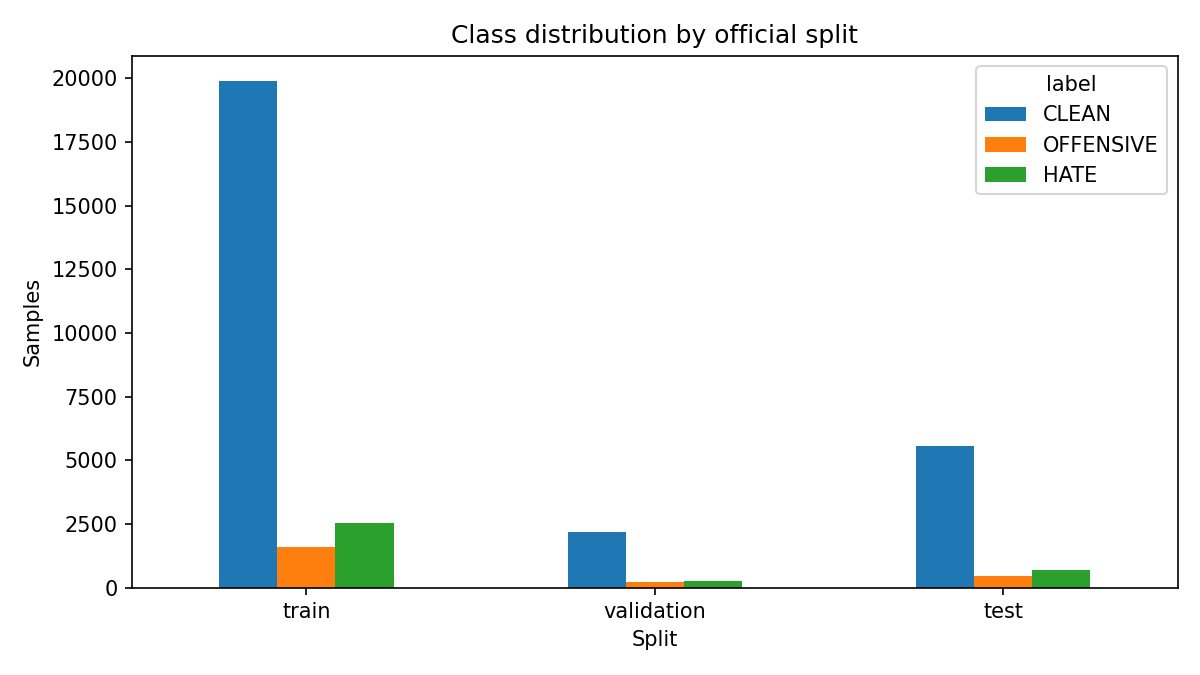

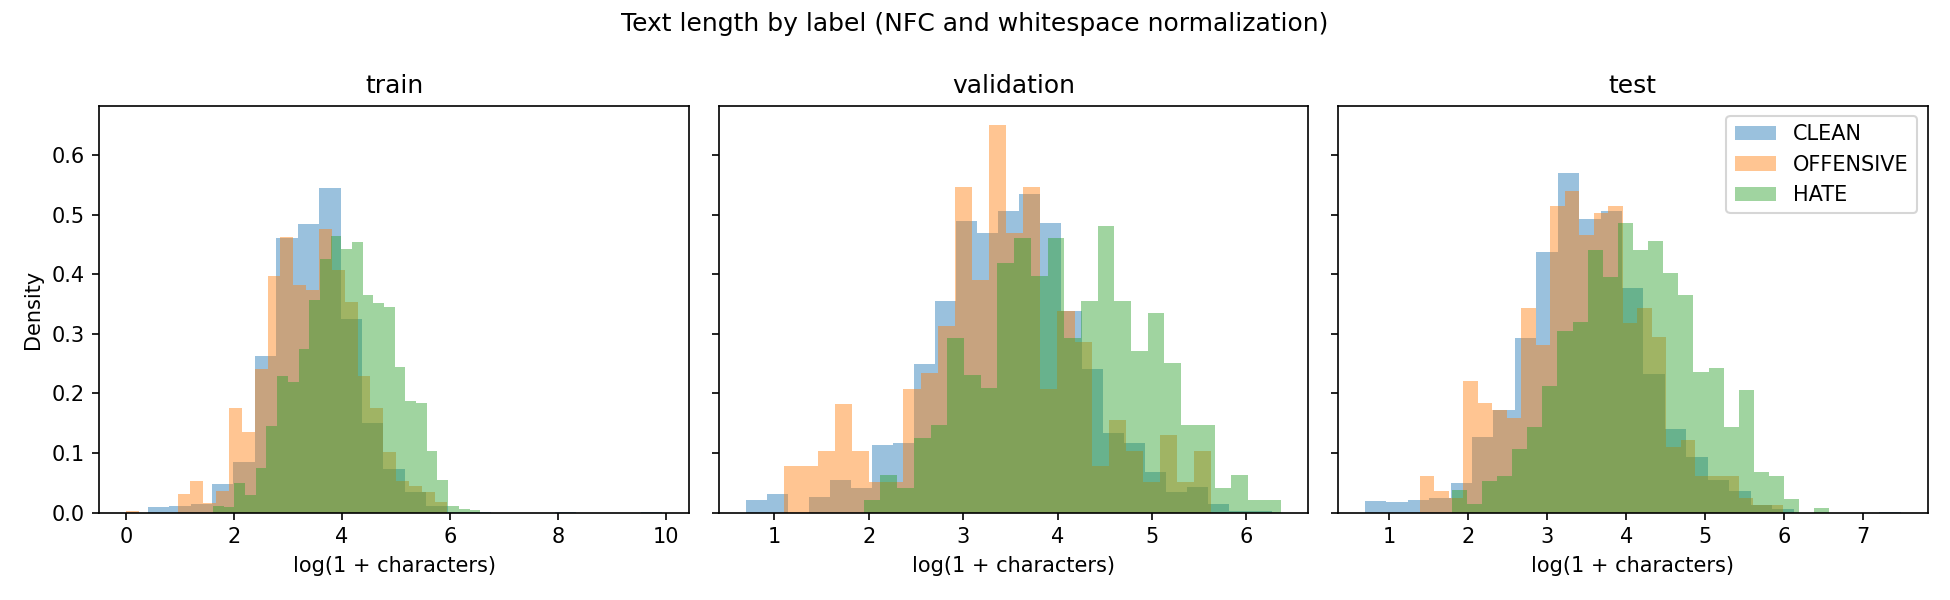

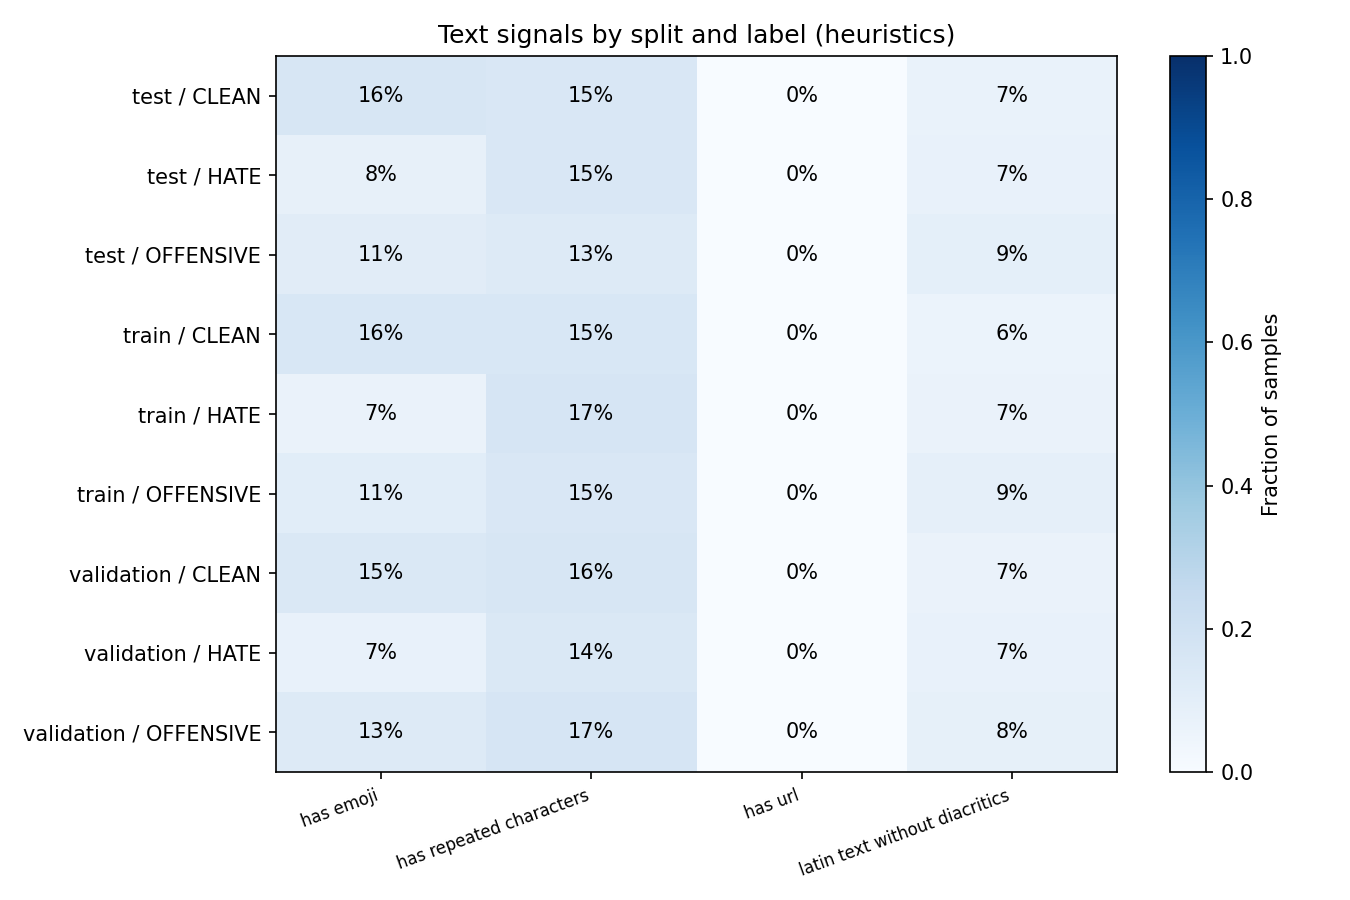

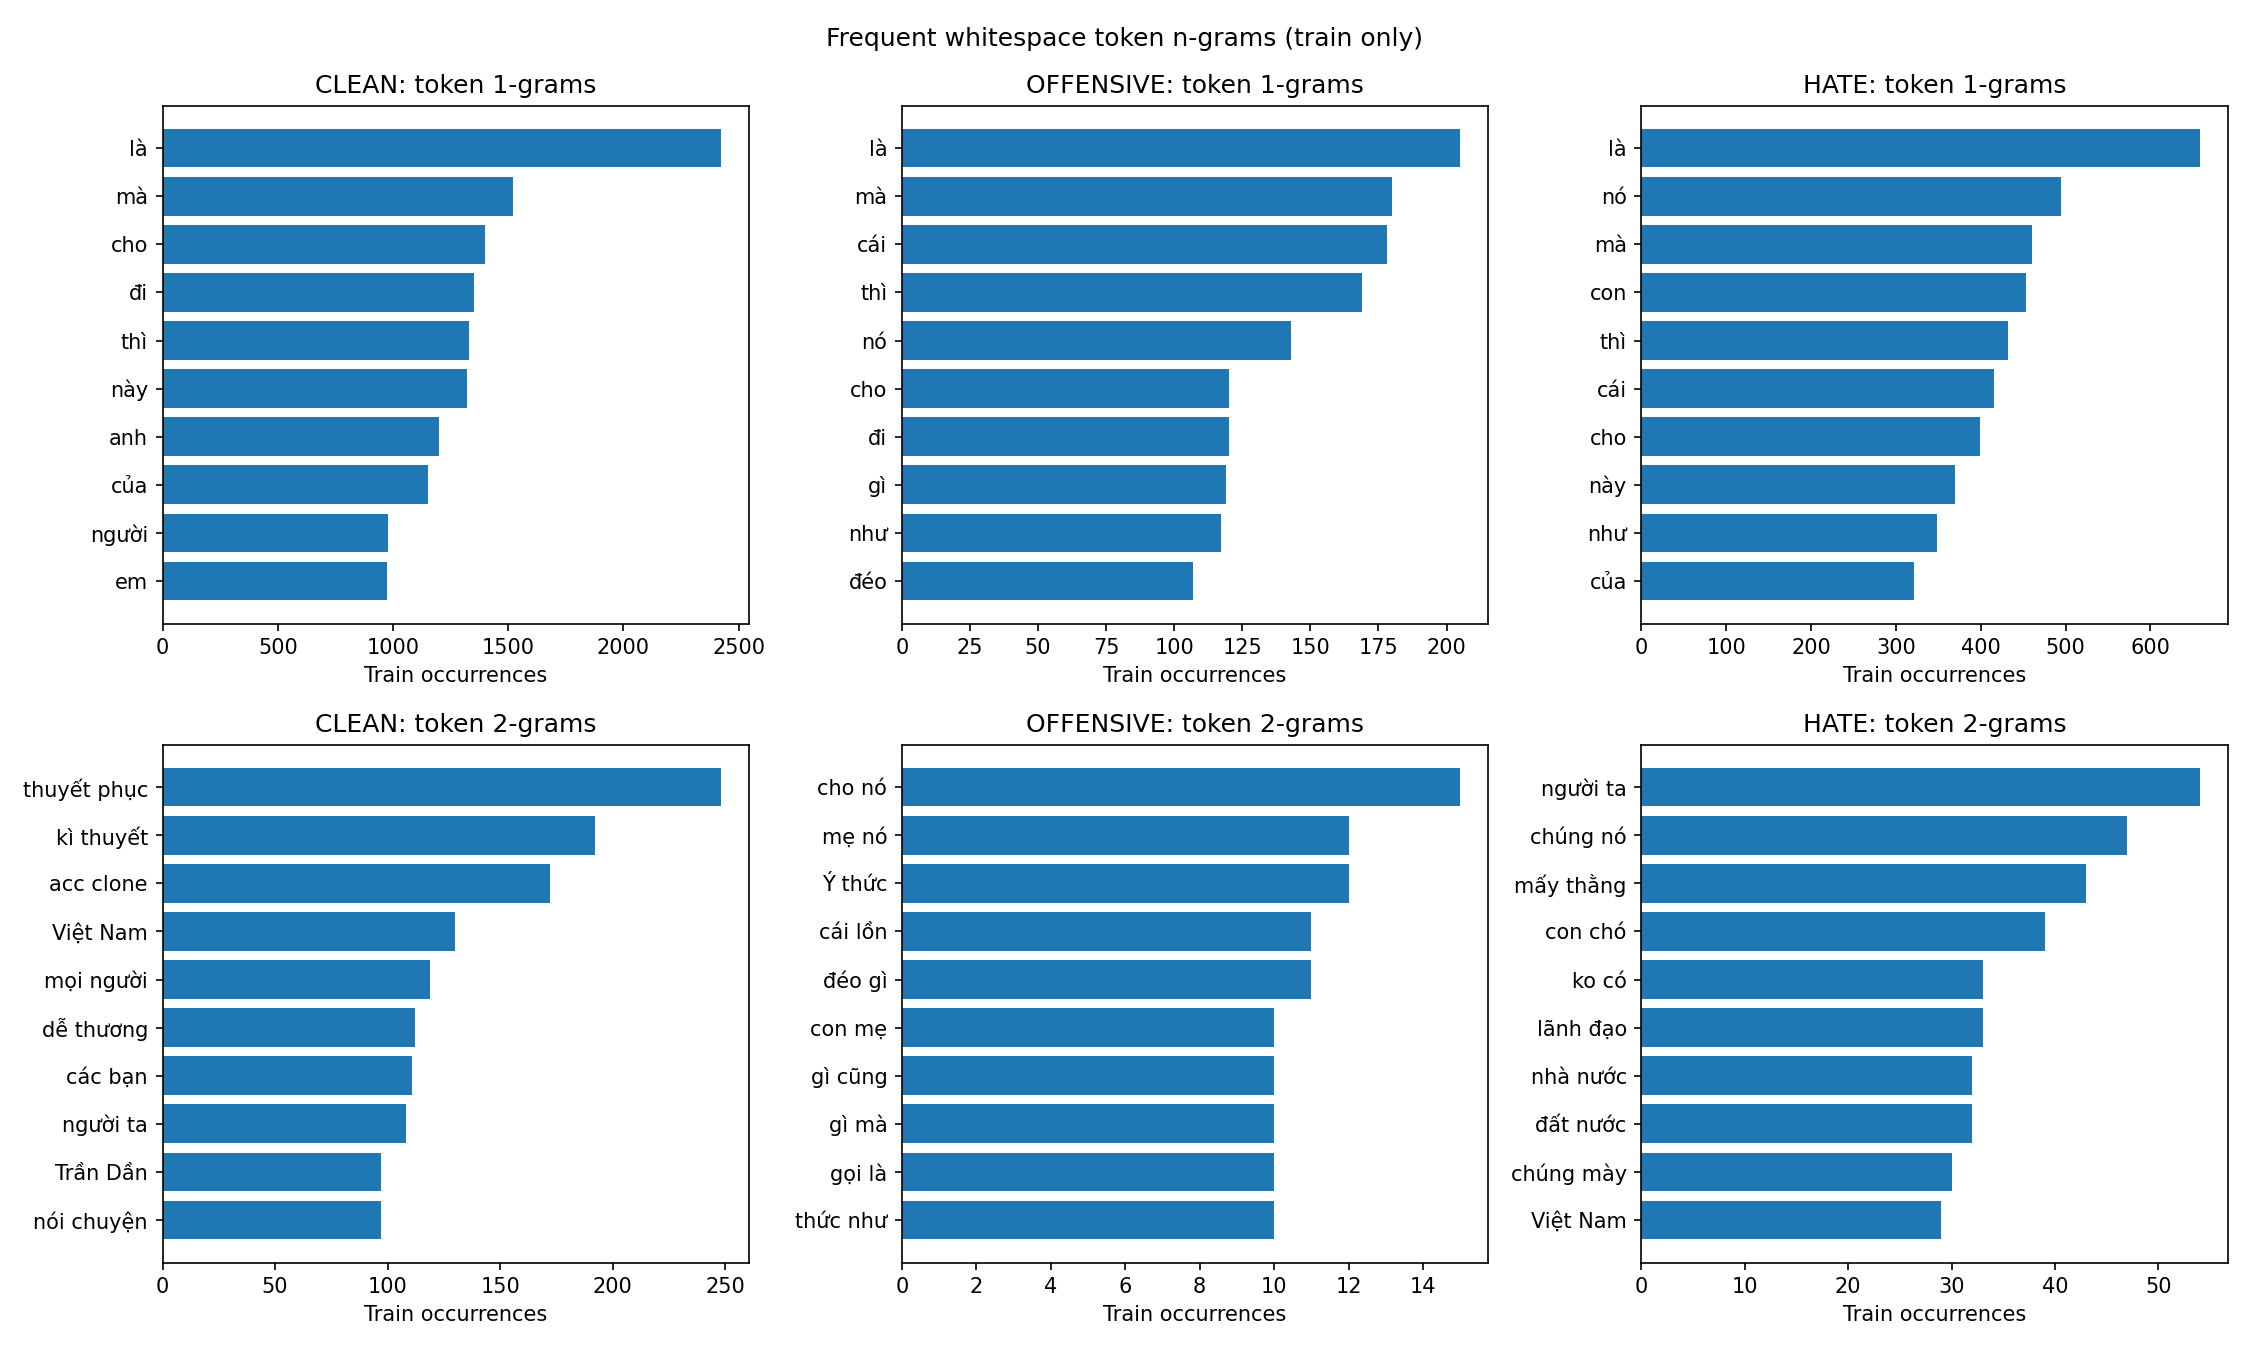

In [9]:
bundle = None
if RUN_LOAD_DATA:
    bundle = load_github_dataset(revision=DATA_REVISION, cache_dir=DATA_CACHE_DIR)
    DATA_REVISION = bundle.manifest["revision"]
    display(pd.Series({k: bundle.manifest.get(k) for k in
                       ["dataset", "source", "revision", "fingerprint", "synthetic"]}).to_frame("Giá trị"))
    display(pd.Series(bundle.manifest["split_counts"]).to_frame("Số mẫu"))
    print("Ghi lại DATA_REVISION cho phiên sau:", DATA_REVISION)
if RUN_EDA:
    assert bundle is not None, "Bật RUN_LOAD_DATA trước EDA"
    export_eda(bundle, RUN_ROOT / "results/eda")

eda = RUN_ROOT / "results/eda"
eda_manifest = read_json(eda / "manifest.json") if (eda / "manifest.json").exists() else None
expected_fingerprint = bundle.manifest["fingerprint"] if bundle else (run_metadata or {}).get("dataset_fingerprint")
eda_matches = bool(eda_manifest) and (expected_fingerprint is None or
              eda_manifest.get("fingerprint") == expected_fingerprint)
if eda_manifest and eda_manifest.get("synthetic", False):
    print("EDA đã lưu là fixture tổng hợp; không hiển thị như kết quả ViHSD.")
elif eda_manifest and not eda_matches:
    print("Fingerprint EDA khác dataset đang nạp; cần EDA đúng dataset.")
elif eda_matches:
    for file in sorted(eda.glob("*.json")):
        print(file.name)
        display(read_json(file))
    for file in sorted(eda.glob("*.png")):
        display(Image(filename=str(file)))
else:
    print("Chưa có EDA ViHSD. Bật tải/EDA khi muốn thực nghiệm; chế độ hiện tại không gọi mạng.")

### Nhận xét EDA cần hoàn thành

Ghi từ kết quả thật: số mẫu/lớp mỗi split, mất cân bằng, độ dài theo lớp, emoji/URL/không dấu,
null/rỗng, nhãn mâu thuẫn, trùng giữa split. Không âm thầm xóa dòng hay đổi split; nếu chạy
thực nghiệm loại trùng, lưu manifest/bảng riêng. Đọc định nghĩa nhãn của ViHSD.
Không coi ghi chú này là phân tích EDA đã hoàn thành.

Hai cấu hình `experiments.yaml` và `traditional.yaml` chọn rõ `empty_text_policy: keep`:
giữ nguyên mọi dòng/ID/nhãn/split và fingerprint, kể cả chuỗi rỗng hoặc chỉ có khoảng trắng.
Không chèn placeholder và không bỏ dòng. Chuỗi này thành `""` sau chuẩn hóa: TF-IDF nhận
vector toàn 0, Transformer nhận special tokens của tokenizer. Null/giá trị không phải
chuỗi vẫn bị từ chối; cấu hình không khai báo policy mặc định là `error`.
Cell training hiển thị số chuỗi rỗng từng split và lưu policy/số lượng trong
`metadata.json → text_validation` để báo cáo quyết định này.

## 3. Tiền xử lý và công bằng thực nghiệm

Các model dùng cùng mẫu/nhãn/split. NFC/khoảng trắng, giữ dấu, emoji và phủ định.
SVM/LR dùng TF-IDF token `(1,2)`, char `(3,5)` hoặc kết hợp; token tách khoảng trắng thường
là âm tiết. Fit vocabulary/IDF chỉ trên train. **PhoBERT dùng PyVi tách từ** theo yêu cầu
đầu vào; **BamiBERT dùng văn bản chưa tách từ**. PyVi gọn cho Colab nhưng khác VnCoreNLP dùng
khi pretrain PhoBERT; ghi lựa chọn này trong báo cáo. Chỉ chuẩn hóa bổ sung khi cấu hình lưu rõ.

Checkpoint gốc: `vinai/phobert-base`, `Qualcomm-AI-Research/BamiBERT`. Không dùng model
đang chạy của extension thay cho thí nghiệm fine-tune cùng split. Ghi exact revision trong
metadata, không suy ra BamiBERT tốt hơn vì mới hơn. Kiểm tra tokenizer/truncation trên
train/dev khi cân nhắc 128 hoặc 256 token; không dùng test để chọn độ dài.


## 4. Huấn luyện, checkpoint và resume

SVM/LR thử cùng ngân sách TF-IDF rồi tune classifier; SVM calibration sigmoid qua CV
trên train, bọc cả vectorizer trong từng fold. Transformer dùng 3 epoch, max length 128,
batch 8 và gradient accumulation 2 làm cấu hình khởi đầu; chọn checkpoint bằng dev Macro-F1.
Mixed precision chỉ dùng khi thiết bị phù hợp. Ngân sách compute khác nhau giữa hai họ
mô hình, phải báo đúng thay vì gọi toàn bộ tìm kiếm là ngang nhau.

`RUN_TRAINING=True` yêu cầu dữ liệu thật và run ID rõ ràng. Khi gián đoạn, resume chỉ khả thi
nếu checkpoint vẫn tồn tại; Drive giúp giữ chúng qua các phiên Colab. Cùng code/config/runtime
và fingerprint là điều kiện để resume. Không retrain train+dev rồi dùng lại threshold/test cũ.


In [ ]:
if RUN_TRAINING and not IMBALANCE_STUDY:
    assert bundle is not None, "Bật RUN_LOAD_DATA và xem EDA trước train"
    assert RUN_ID, "Chọn RUN_ID mới; resume dùng cùng RUN_ID cũ"
    assert not bundle.manifest.get("synthetic", False), "Không dùng fixture cho báo cáo ViHSD"
    text_validation = validate_training_data(
        bundle, empty_text_policy=CONFIG.get("empty_text_policy", "error")
    )
    print("Policy text rỗng:", text_validation["empty_text_policy"])
    display(pd.Series(text_validation["empty_text_counts"]).to_frame("Số chuỗi rỗng"))
    train_experiment(bundle, CONFIG, RUN_ROOT, RUN_ID, resume=RESUME_TRAINING)
    RUN = RUN_ROOT / "results/runs" / RUN_ID

selection = read_json(RUN / "selection.json") if RUN and (RUN / "selection.json").exists() else None
if selection and selection.get("synthetic") is not False:
    print("Run tổng hợp/không rõ provenance không phải kết quả nghiên cứu.")
    selection = None
if selection and bundle is not None and selection["dataset_fingerprint"] != bundle.manifest["fingerprint"]:
    raise ValueError("Run và bundle khác fingerprint; chọn lại đúng dataset/run.")
if selection:
    FROZEN_CONFIG = read_json(RUN / "config.json")
    assert sha256(RUN / "config.json") == selection["config_sha256"], "Cấu hình đã đổi sau khóa"
    expected_families = set(FROZEN_CONFIG["models"])
    candidate_families = [candidate["family"] for candidate in selection["candidates"]]
    assert len(candidate_families) == len(expected_families) and set(candidate_families) == expected_families, "Finalist khác cấu hình đã khóa"
    display(Markdown("**Cấu hình đã khóa của run đang xem**"))
    display(FROZEN_CONFIG)
    display(pd.read_csv(RUN / "tuning_results.csv"))
else:
    print("Chưa có selection đã khóa; không có bảng so sánh thật để báo cáo.")

## 5. Train/dev, reliability và đường học

Xếp hạng nghiên cứu theo Macro-F1 dev của pipeline hoàn chỉnh sau calibration nếu có.
Báo chênh lệch train/dev và F1 từng lớp. SVM/LR dùng learning curves theo số mẫu;
Transformer dùng loss/dev metrics theo epoch, không coi hai trục này là cùng một phép đo.
Softmax là đầu ra xác suất nhưng không bảo đảm calibration tốt; xem reliability/log loss.

CPU latency được đo sau cả preprocessing trên cùng máy để tham chiếu Space; p50/p95 API
còn gồm mạng, queue và khởi động. Môi trường Colab và CPU Basic khác nhau, không chuyển
số đo cục bộ thành cam kết latency cho extension.


,family,backend,feature_kind,min_df,raw_validation_macro_f1,validation_macro_f1,calibrated,threshold,fit_seconds,artifact_bytes,gap_from_best_percentage_points
0,phobert,transformers,pretrained_tokenizer,NaN,0.675702,0.675702,False,0.186870,765.511798,542061485,0.000000
1,bamibert,transformers,pretrained_tokenizer,NaN,0.665500,0.665500,False,0.259343,663.674757,413275513,1.020233
2,logistic_regression,sklearn,combined,3.0,0.613812,0.613812,False,0.546055,20.093916,2288209,6.189001
3,svm,sklearn,combined,3.0,0.625121,0.595497,True,0.348419,20.262573,4546190,8.020466


### svm

train_metrics.json


{'n_samples': 24048,
 'accuracy': 0.9446523619427811,
 'macro_f1': 0.8523409567627481,
 'weighted_f1': 0.9414826759901911,
 'per_class': {'CLEAN': {'precision': 0.9515832284303283,
   'recall': 0.988333500955446,
   'f1': 0.969610261470153,
   'support': 19886},
  'OFFENSIVE': {'precision': 0.9171322160148976,
   'recall': 0.6133250311332503,
   'f1': 0.7350746268656716,
   'support': 1606},
  'HATE': {'precision': 0.8956896551724138,
   'recall': 0.8129890453834115,
   'f1': 0.85233798195242,
   'support': 2556}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[19654, 70, 162],
   [541, 985, 80],
   [459, 19, 2078]],
  'normalized': [[0.988333500955446,
    0.00352006436689128,
    0.008146434677662677],
   [0.3368617683686177, 0.6133250311332503, 0.049813200498132],
   [0.1795774647887324, 0.007433489827856025, 0.8129890453834115]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division': 0}

validation_metrics.json


...

{'fit_seconds': 20.262572771000123,
 'peak_process_rss_mb': 1052.21875,
 'incremental_peak_rss_mb': 114.359375,
 'warnings': [],
 'artifact_bytes': 4546190,
 'feature_count_per_estimator': [71325]}

latency.json


{'scope': 'warm in-process predict_proba on raw text; includes pipeline preprocessing and vectorization',
 'excludes': ['model loading',
  'API/network',
  'extension routing',
  'UI rendering'],
 'hardware': {'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
  'machine': 'x86_64',
  'processor_reported': 'x86_64',
  'logical_cpu_count': 2,
  'python_version': '3.13.15',
  'thread_environment': {'OMP_NUM_THREADS': None,
   'OPENBLAS_NUM_THREADS': None,
   'MKL_NUM_THREADS': None,
   'VECLIB_MAXIMUM_THREADS': None}},
 'input_sample_count': 128,
 'input_character_length': {'p50': 31.0, 'p95': 121.59999999999997},
 'batches': [{'batch_size': 1,
   'repeats': 30,
   'warmup_calls': 3,
   'batch_latency_ms_p50': 2.382861,
   'batch_latency_ms_p95': 2.8518638999999997,
   'batch_latency_ms_mean': 2.488981966666666,
   'amortized_ms_per_item_p50': 2.382861,
   'items_per_second': 401.7706891381121},
  {'batch_size': 8,
   'repeats': 30,
   'warmup_calls': 3,
   'batch_latency_ms_p50': 3.514

learning_curve.csv


,fraction,train_size,fit_seconds,reused_final_fit,train_macro_f1,validation_macro_f1
0,0.25,6012,5.285133,False,0.893815,0.523143
1,0.50,12024,9.805094,False,0.870441,0.563698
2,0.75,18036,17.208920,False,0.857466,0.590581
3,1.00,24048,0.000000,True,0.852341,0.595497


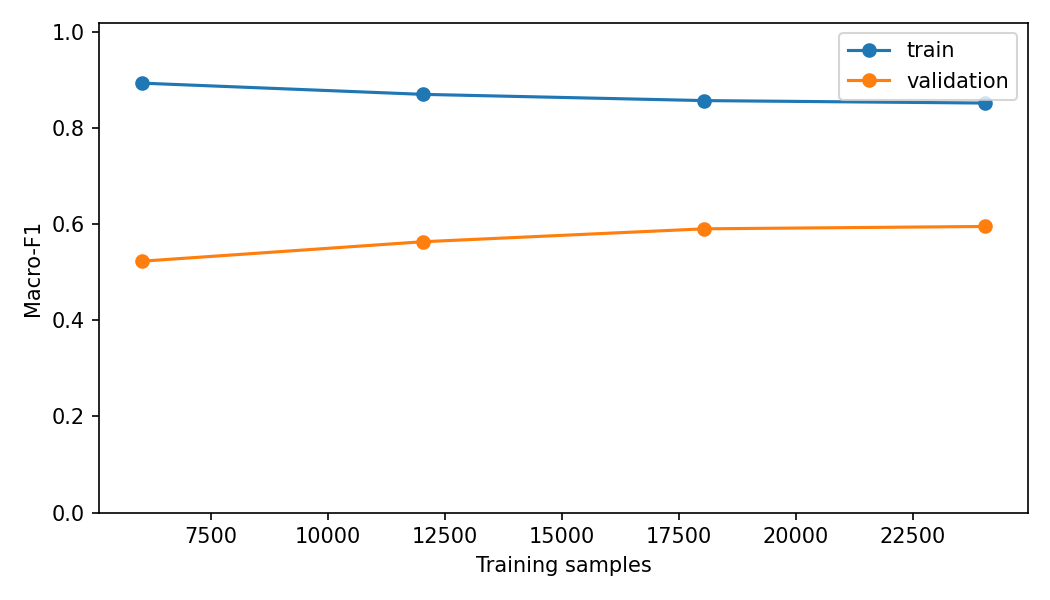

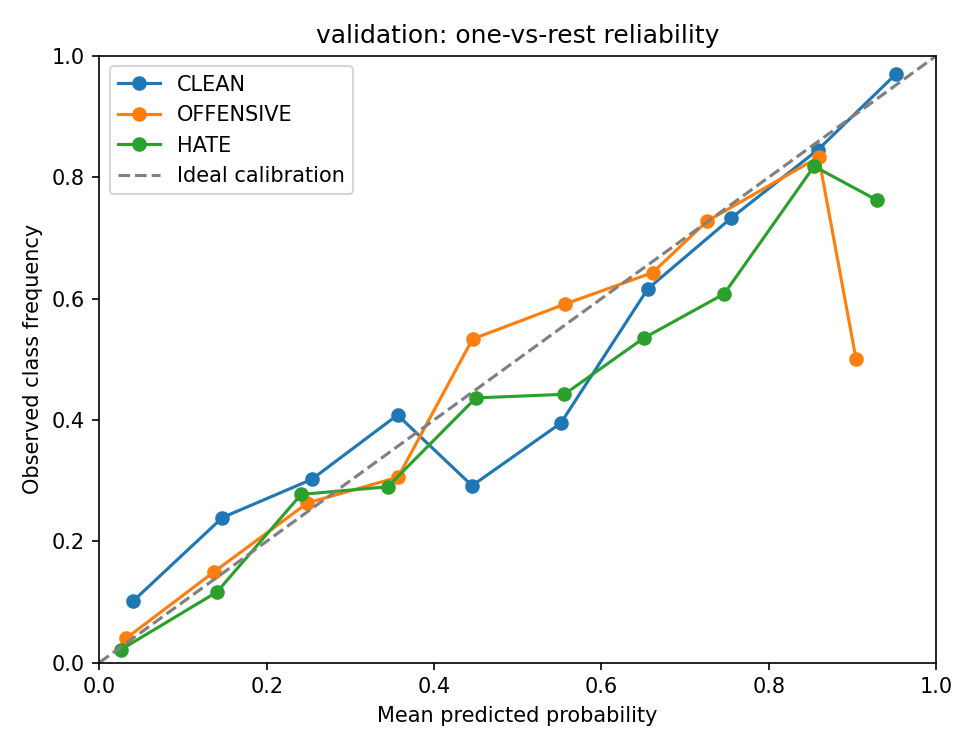

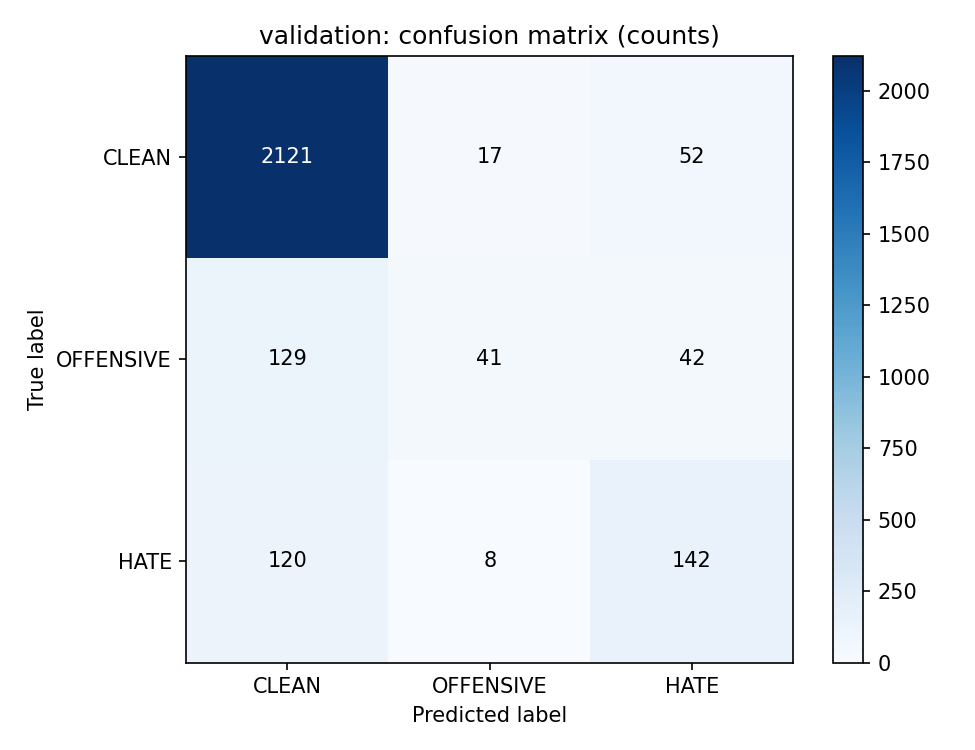

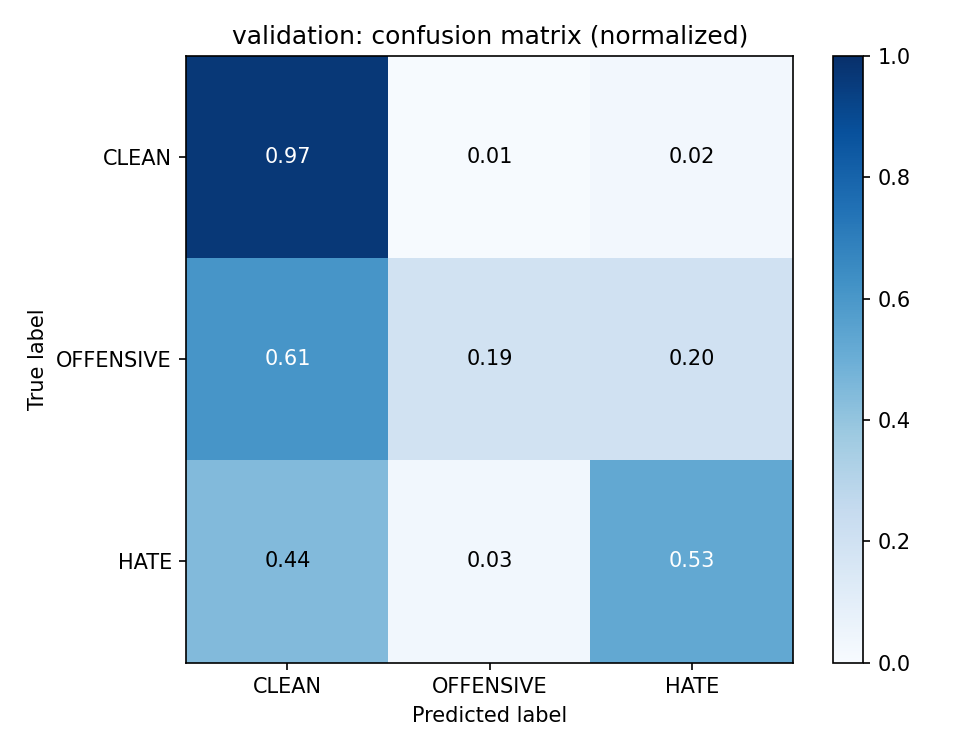

### logistic_regression

train_metrics.json


{'n_samples': 24048,
 'accuracy': 0.978709248170326,
 'macro_f1': 0.9538019565373429,
 'weighted_f1': 0.9791928936360631,
 'per_class': {'CLEAN': {'precision': 0.9993307593307593,
   'recall': 0.9761641355727647,
   'f1': 0.9876116099819389,
   'support': 19886},
  'OFFENSIVE': {'precision': 0.8710382513661202,
   'recall': 0.9925280199252802,
   'f1': 0.9278230500582072,
   'support': 1606},
  'HATE': {'precision': 0.9058360186179735,
   'recall': 0.9898278560250391,
   'f1': 0.9459712095718826,
   'support': 2556}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[19412, 211, 263],
   [12, 1594, 0],
   [1, 25, 2530]],
  'normalized': [[0.9761641355727647,
    0.010610479734486573,
    0.013225384692748667],
   [0.007471980074719801, 0.9925280199252802, 0.0],
   [0.0003912363067292645, 0.009780907668231613, 0.9898278560250391]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division': 0}

validation_metrics.json


{'n_samples': 2672,
 'accuracy': 0.8424401197604791,
 'macro_f1': 0.6138119912136398,
 'weighted_f1': 0.8425270124369751,
 'per_class': {'CLEAN': {'precision': 0.9286372007366482,
   'recall': 0.9210045662100457,
   'f1': 0.9248051352590555,
   'support': 2190},
  'OFFENSIVE': {'precision': 0.4114285714285714,
   'recall': 0.33962264150943394,
   'f1': 0.37209302325581395,
   'support': 212},
  'HATE': {'precision': 0.49846153846153846,
   'recall': 0.6,
   'f1': 0.5445378151260504,
   'support': 270}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[2017, 69, 104], [81, 72, 59], [74, 34, 162]],
  'normalized': [[0.9210045662100457,
    0.031506849315068496,
    0.047488584474885846],
   [0.38207547169811323, 0.33962264150943394, 0.2783018867924528],
   [0.2740740740740741, 0.1259259259259259, 0.6]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division': 0,
 'calibration': {'log_loss': 0.44670793481

...

{'fit_seconds': 20.093916433999993,
 'peak_process_rss_mb': 1156.44921875,
 'incremental_peak_rss_mb': 42.828125,
 'warnings': ['DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.'],
 'artifact_bytes': 2288209,
 'feature_count_per_estimator': [71325]}

latency.json


{'scope': 'warm in-process predict_proba on raw text; includes pipeline preprocessing and vectorization',
 'excludes': ['model loading',
  'API/network',
  'extension routing',
  'UI rendering'],
 'hardware': {'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
  'machine': 'x86_64',
  'processor_reported': 'x86_64',
  'logical_cpu_count': 2,
  'python_version': '3.13.15',
  'thread_environment': {'OMP_NUM_THREADS': None,
   'OPENBLAS_NUM_THREADS': None,
   'MKL_NUM_THREADS': None,
   'VECLIB_MAXIMUM_THREADS': None}},
 'input_sample_count': 128,
 'input_character_length': {'p50': 31.0, 'p95': 121.59999999999997},
 'batches': [{'batch_size': 1,
   'repeats': 30,
   'warmup_calls': 3,
   'batch_latency_ms_p50': 2.4174415,
   'batch_latency_ms_p95': 2.8980021,
   'batch_latency_ms_mean': 2.4655194000000002,
   'amortized_ms_per_item_p50': 2.4174415,
   'items_per_second': 405.5940504868872},
  {'batch_size': 8,
   'repeats': 30,
   'warmup_calls': 3,
   'batch_latency_ms_p50': 3.491374999

learning_curve.csv


,fraction,train_size,fit_seconds,reused_final_fit,train_macro_f1,validation_macro_f1
0,0.25,6012,4.948895,False,0.984930,0.581850
1,0.50,12024,11.830227,False,0.973125,0.606486
2,0.75,18036,14.850147,False,0.964737,0.607981
3,1.00,24048,0.000000,True,0.953802,0.613812


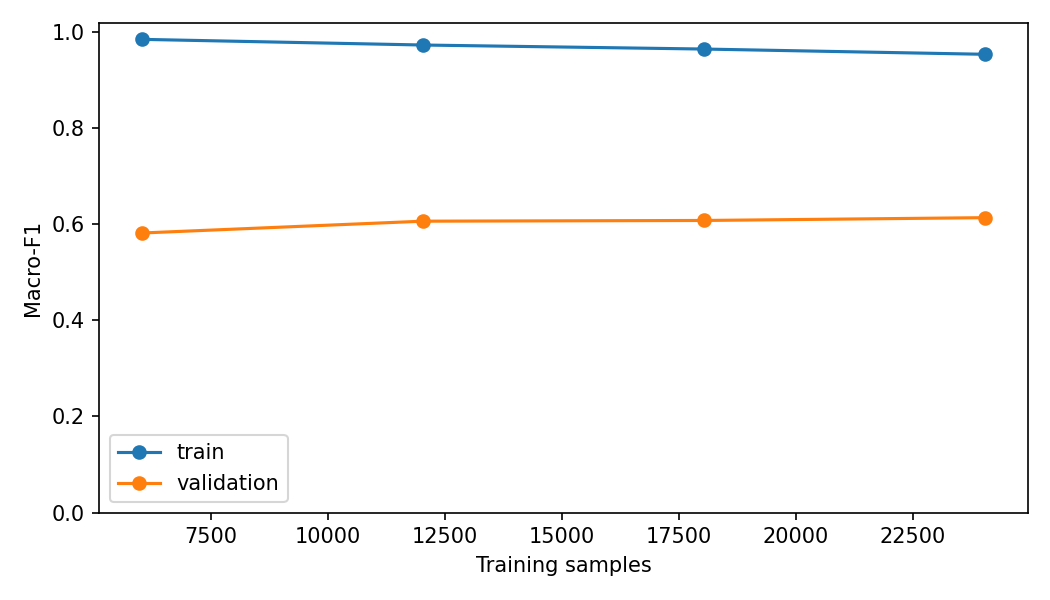

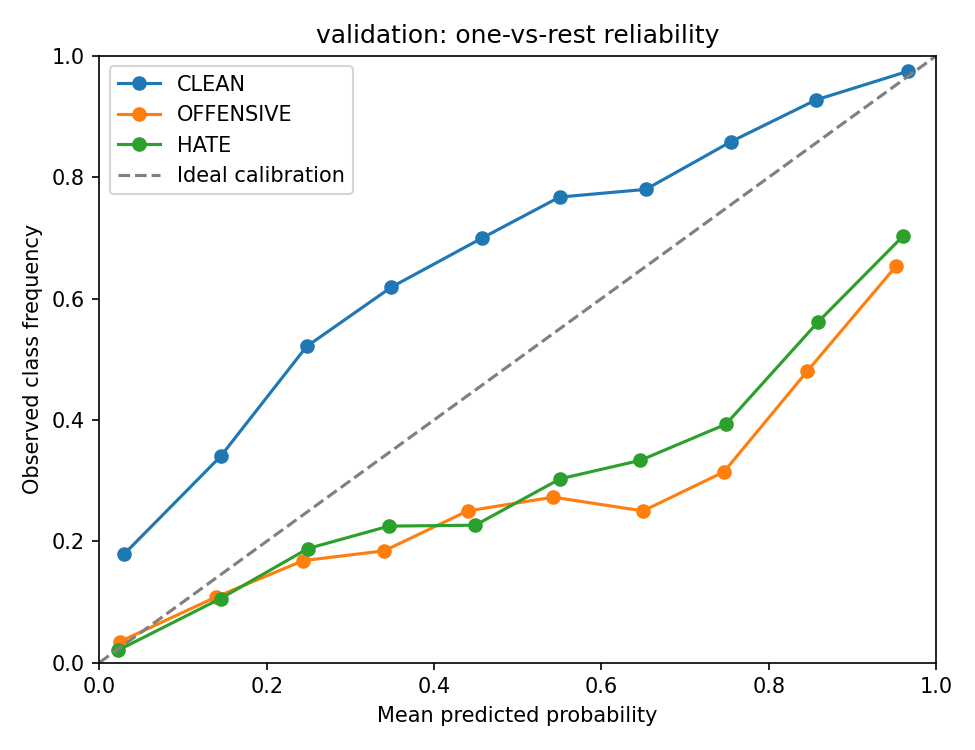

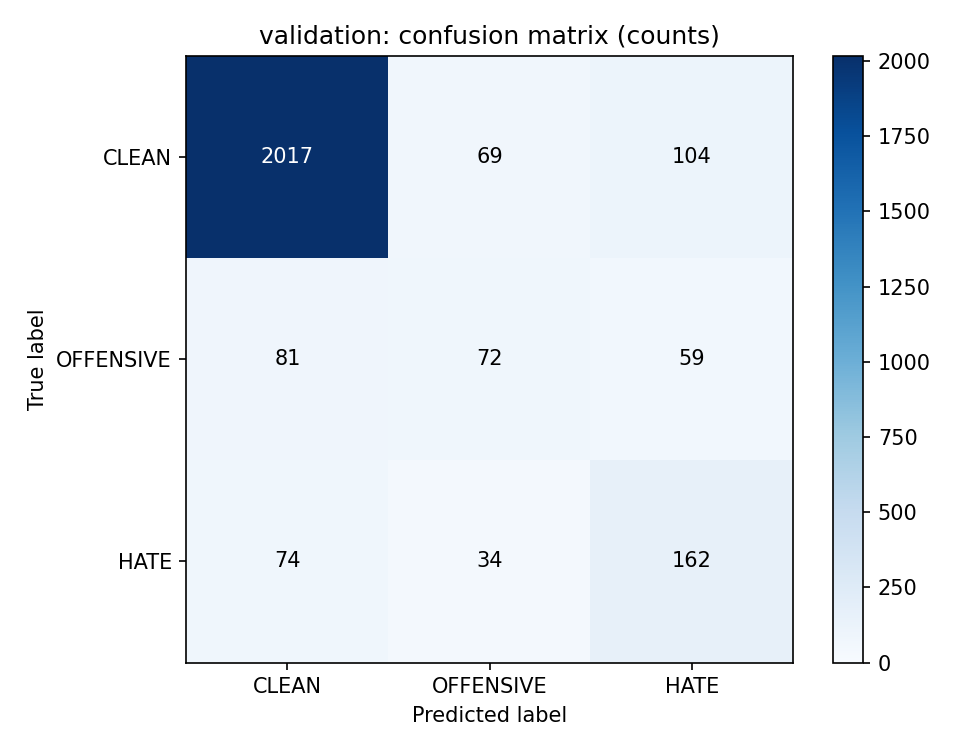

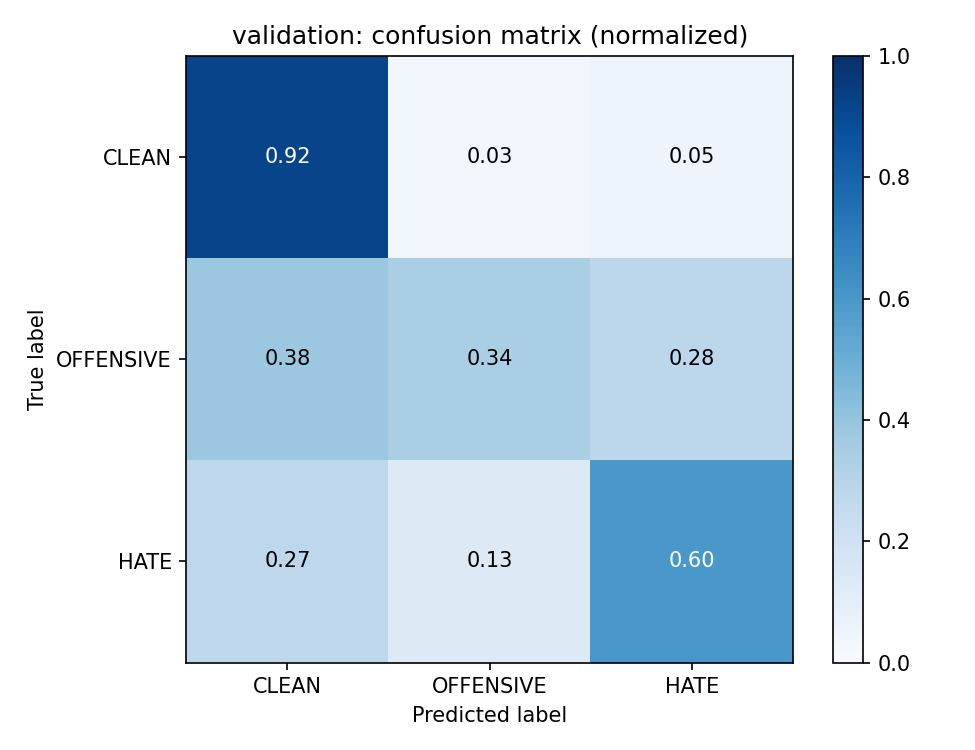

### phobert

train_metrics.json


{'n_samples': 24048,
 'accuracy': 0.9368346640053227,
 'macro_f1': 0.815497931516517,
 'weighted_f1': 0.9341981688646918,
 'per_class': {'CLEAN': {'precision': 0.9598429062346588,
   'recall': 0.9832042643065473,
   'f1': 0.9713831478537361,
   'support': 19886},
  'OFFENSIVE': {'precision': 0.7371294851794071,
   'recall': 0.5884184308841843,
   'f1': 0.6544321329639889,
   'support': 1606},
  'HATE': {'precision': 0.8480801335559266,
   'recall': 0.7949921752738655,
   'f1': 0.8206785137318255,
   'support': 2556}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[19552, 197, 137],
   [434, 945, 227],
   [384, 140, 2032]],
  'normalized': [[0.9832042643065473,
    0.009906466861108318,
    0.006889268832344363],
   [0.27023661270236615, 0.5884184308841843, 0.14134495641344957],
   [0.15023474178403756, 0.054773082942097026, 0.7949921752738655]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division'

validation_metrics.json


{'n_samples': 2672,
 'accuracy': 0.874251497005988,
 'macro_f1': 0.6757019965565862,
 'weighted_f1': 0.8677819301035337,
 'per_class': {'CLEAN': {'precision': 0.9203345070422535,
   'recall': 0.9547945205479452,
   'f1': 0.9372478709099059,
   'support': 2190},
  'OFFENSIVE': {'precision': 0.5827814569536424,
   'recall': 0.41509433962264153,
   'f1': 0.48484848484848486,
   'support': 212},
  'HATE': {'precision': 0.6305220883534136,
   'recall': 0.5814814814814815,
   'f1': 0.605009633911368,
   'support': 270}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[2091, 42, 57], [89, 88, 35], [92, 21, 157]],
  'normalized': [[0.9547945205479452,
    0.019178082191780823,
    0.026027397260273973],
   [0.419811320754717, 0.41509433962264153, 0.1650943396226415],
   [0.34074074074074073, 0.07777777777777778, 0.5814814814814815]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division': 0,
 'calibration': 

...

{'fit_seconds': 765.511797506,
 'peak_process_rss_mb': 3168.36328125,
 'incremental_peak_rss_mb': 2108.2890625,
 'warnings': ['DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utc

latency.json


{'scope': 'warm CPU raw-text preprocessing, tokenization and Transformer inference',
 'excludes': ['model loading',
  'API/network',
  'extension routing',
  'UI rendering'],
 'hardware': {'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
  'machine': 'x86_64',
  'processor_reported': 'x86_64',
  'logical_cpu_count': 2,
  'python_version': '3.13.15',
  'thread_environment': {'OMP_NUM_THREADS': None,
   'OPENBLAS_NUM_THREADS': None,
   'MKL_NUM_THREADS': None,
   'VECLIB_MAXIMUM_THREADS': None}},
 'input_sample_count': 128,
 'input_character_length': {'p50': 31.0, 'p95': 121.59999999999997},
 'batches': [{'batch_size': 1,
   'repeats': 5,
   'warmup_calls': 1,
   'batch_latency_ms_p50': 96.59695,
   'batch_latency_ms_p95': 123.9019586,
   'batch_latency_ms_mean': 93.610399,
   'amortized_ms_per_item_p50': 96.59695,
   'items_per_second': 10.682573845241274},
  {'batch_size': 8,
   'repeats': 5,
   'warmup_calls': 1,
   'batch_latency_ms_p50': 472.907479,
   'batch_latency_ms_p95': 629

training_history.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.0662,5.407258,2.084257e-06,0.033267,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.7326,2.420466,4.212860e-06,0.066534,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.6013,9.903808,6.385809e-06,0.099800,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.6037,4.091449,8.603104e-06,0.133067,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5854,3.583663,1.082040e-05,0.166334,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0.2221,9.484272,5.717102e-07,2.927478,4400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,0.2520,11.335022,3.252834e-07,2.960745,4450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,0.2104,10.484388,7.885658e-08,2.994012,4500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,3.000000,4509,0.397874,0.675702,2.8151,949.176,59.324,NaN,NaN,NaN,NaN,NaN


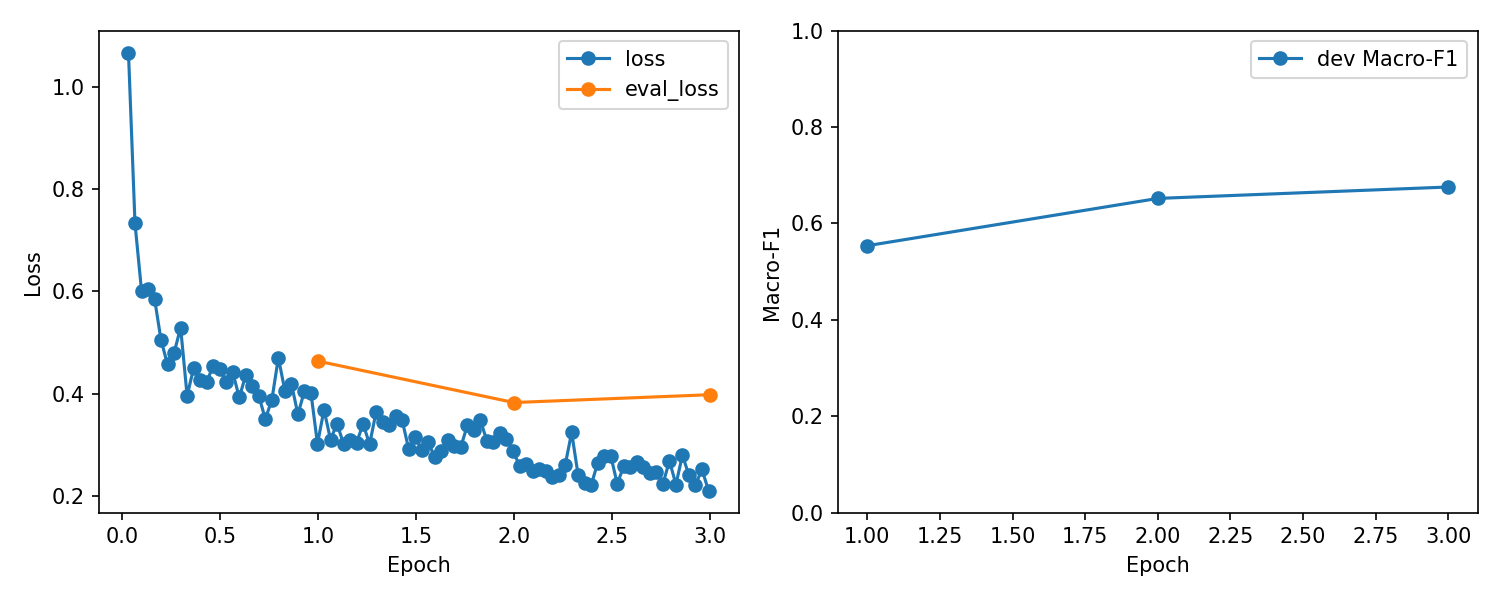

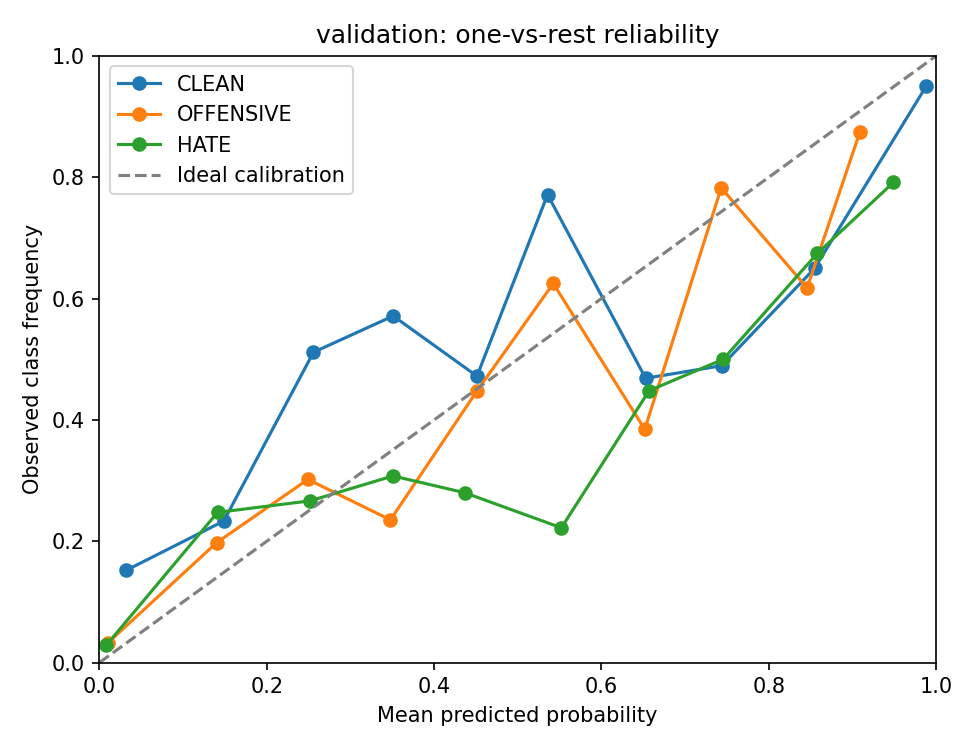

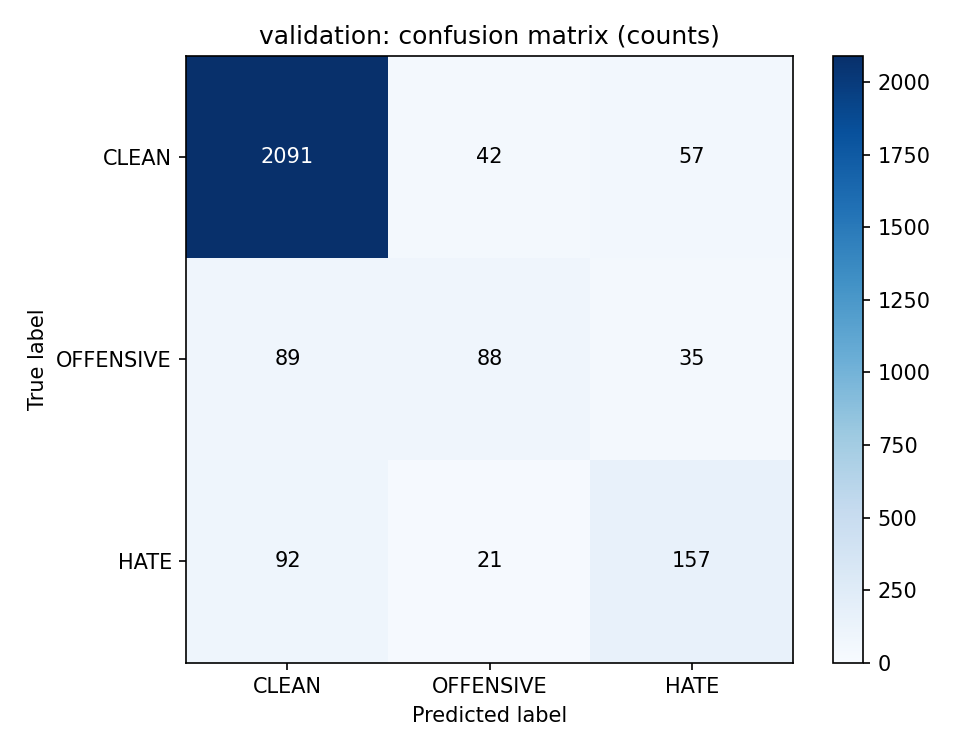

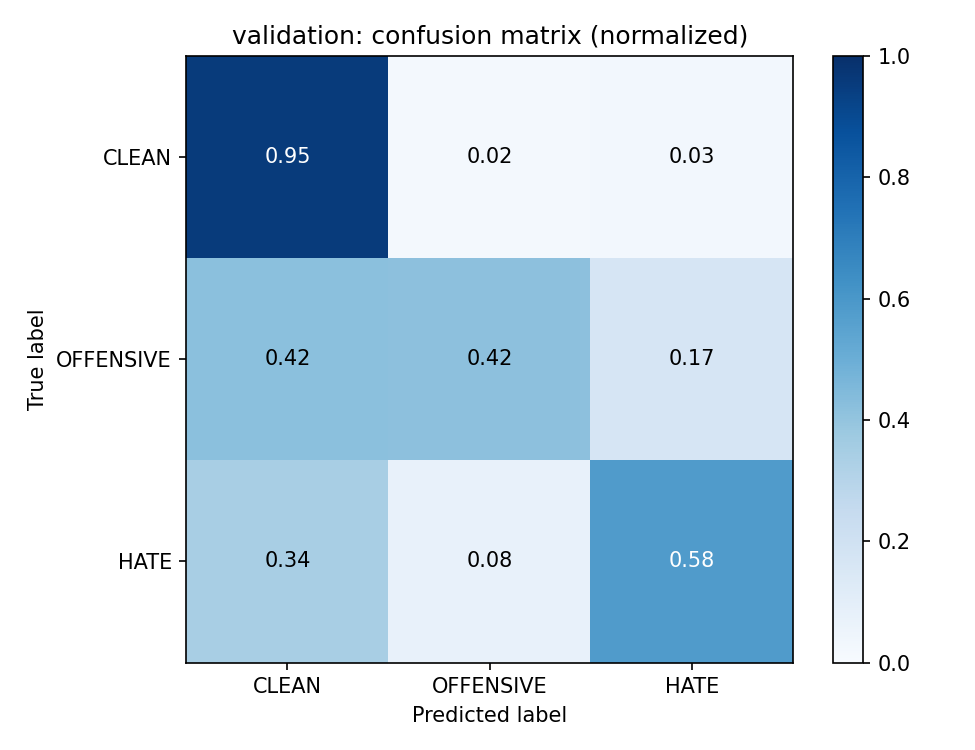

### bamibert

train_metrics.json


{'n_samples': 24048,
 'accuracy': 0.9363356620093147,
 'macro_f1': 0.8125746477049111,
 'weighted_f1': 0.9346681434199898,
 'per_class': {'CLEAN': {'precision': 0.9674037267080745,
   'recall': 0.9790304737000906,
   'f1': 0.973182374846917,
   'support': 19886},
  'OFFENSIVE': {'precision': 0.7147102526002972,
   'recall': 0.5990037359900373,
   'f1': 0.6517615176151762,
   'support': 1606},
  'HATE': {'precision': 0.8094683740783857,
   'recall': 0.8161189358372457,
   'f1': 0.8127800506526398,
   'support': 2556}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[19469, 221, 196],
   [349, 962, 295],
   [307, 163, 2086]],
  'normalized': [[0.9790304737000906,
    0.011113346072613899,
    0.009856180227295584],
   [0.21731008717310088, 0.5990037359900373, 0.18368617683686178],
   [0.12010954616588419, 0.06377151799687011, 0.8161189358372457]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division':

validation_metrics.json


{'n_samples': 2672,
 'accuracy': 0.8708832335329342,
 'macro_f1': 0.6654996703854668,
 'weighted_f1': 0.8659533365618122,
 'per_class': {'CLEAN': {'precision': 0.928795342588446,
   'recall': 0.9470319634703196,
   'f1': 0.9378250056522722,
   'support': 2190},
  'OFFENSIVE': {'precision': 0.5652173913043478,
   'recall': 0.36792452830188677,
   'f1': 0.44571428571428573,
   'support': 212},
  'HATE': {'precision': 0.5813953488372093,
   'recall': 0.6481481481481481,
   'f1': 0.6129597197898424,
   'support': 270}},
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'confusion_matrix': {'counts': [[2074, 41, 75], [83, 78, 51], [76, 19, 175]],
  'normalized': [[0.9470319634703196,
    0.01872146118721461,
    0.03424657534246575],
   [0.3915094339622642, 0.36792452830188677, 0.24056603773584906],
   [0.2814814814814815, 0.07037037037037037, 0.6481481481481481]]},
 'confusion_matrix_axes': {'rows': 'true_label', 'columns': 'predicted_label'},
 'zero_division': 0,
 'calibration': 

...

{'fit_seconds': 663.6747568989999,
 'peak_process_rss_mb': 3348.3203125,
 'incremental_peak_rss_mb': 482.3046875,
 'warnings': ['DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).',
  'DeprecationWarning: datetime.datetime.u

latency.json


{'scope': 'warm CPU raw-text preprocessing, tokenization and Transformer inference',
 'excludes': ['model loading',
  'API/network',
  'extension routing',
  'UI rendering'],
 'hardware': {'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
  'machine': 'x86_64',
  'processor_reported': 'x86_64',
  'logical_cpu_count': 2,
  'python_version': '3.13.15',
  'thread_environment': {'OMP_NUM_THREADS': None,
   'OPENBLAS_NUM_THREADS': None,
   'MKL_NUM_THREADS': None,
   'VECLIB_MAXIMUM_THREADS': None}},
 'input_sample_count': 128,
 'input_character_length': {'p50': 31.0, 'p95': 121.59999999999997},
 'batches': [{'batch_size': 1,
   'repeats': 5,
   'warmup_calls': 1,
   'batch_latency_ms_p50': 106.980802,
   'batch_latency_ms_p95': 138.23029459999998,
   'batch_latency_ms_mean': 106.30536040000001,
   'amortized_ms_per_item_p50': 106.980802,
   'items_per_second': 9.406863362649396},
  {'batch_size': 8,
   'repeats': 5,
   'warmup_calls': 1,
   'batch_latency_ms_p50': 573.226564,
   'batch_l

training_history.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.0192,7.817694,2.084257e-06,0.033267,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.6414,38.380104,4.257206e-06,0.066534,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5713,4.716889,6.474501e-06,0.099800,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.5824,9.350952,8.691796e-06,0.133067,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5594,4.729032,1.090909e-05,0.166334,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0.2296,11.041817,5.618531e-07,2.927478,4400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,0.2707,10.395093,3.154263e-07,2.960745,4450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,0.2299,8.629081,6.899951e-08,2.994012,4500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,3.000000,4509,0.388658,0.6655,2.8005,954.128,59.633,NaN,NaN,NaN,NaN,NaN


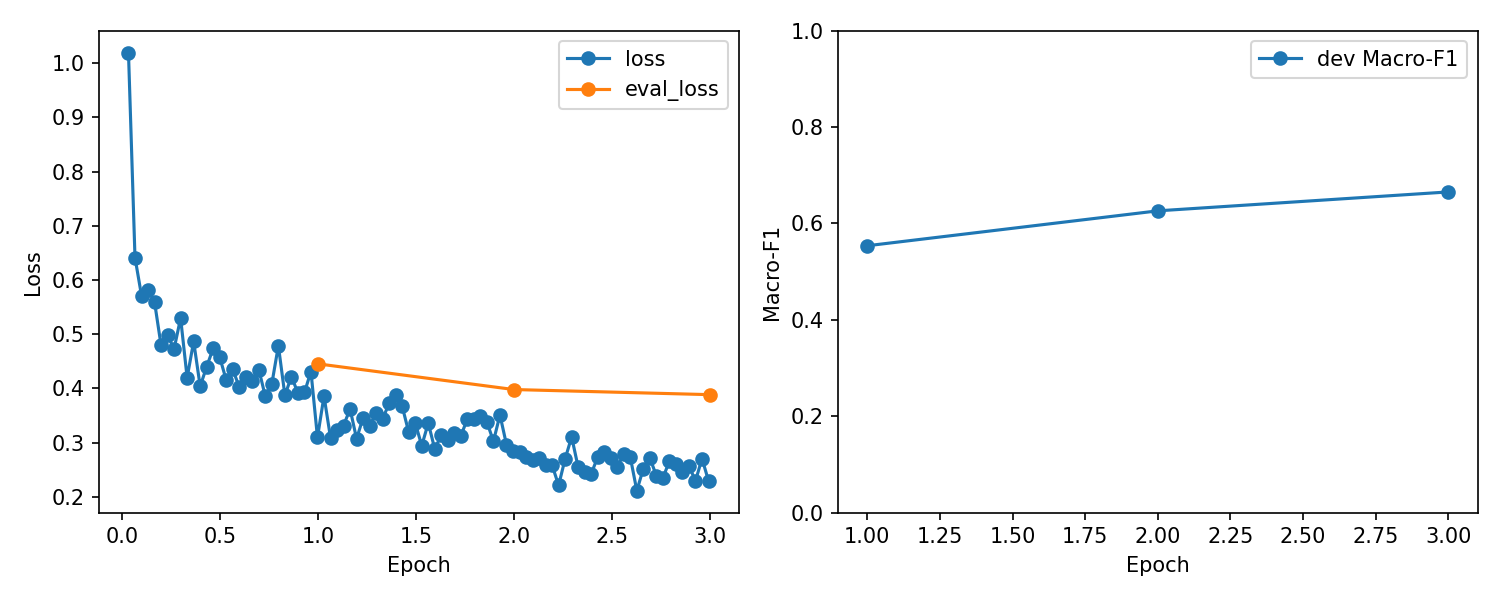

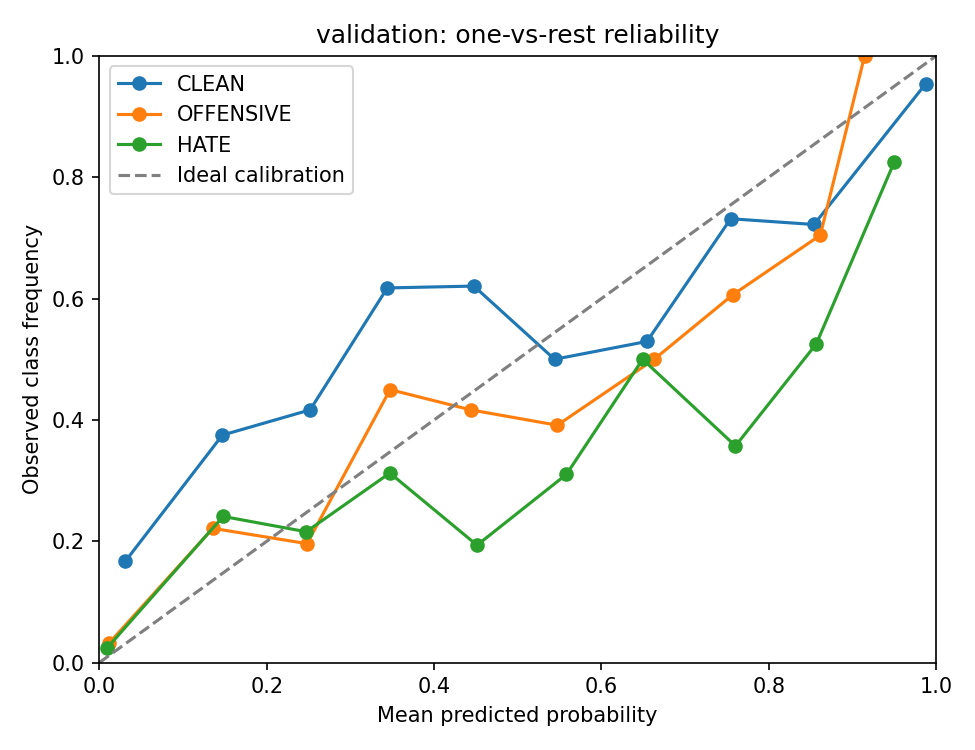

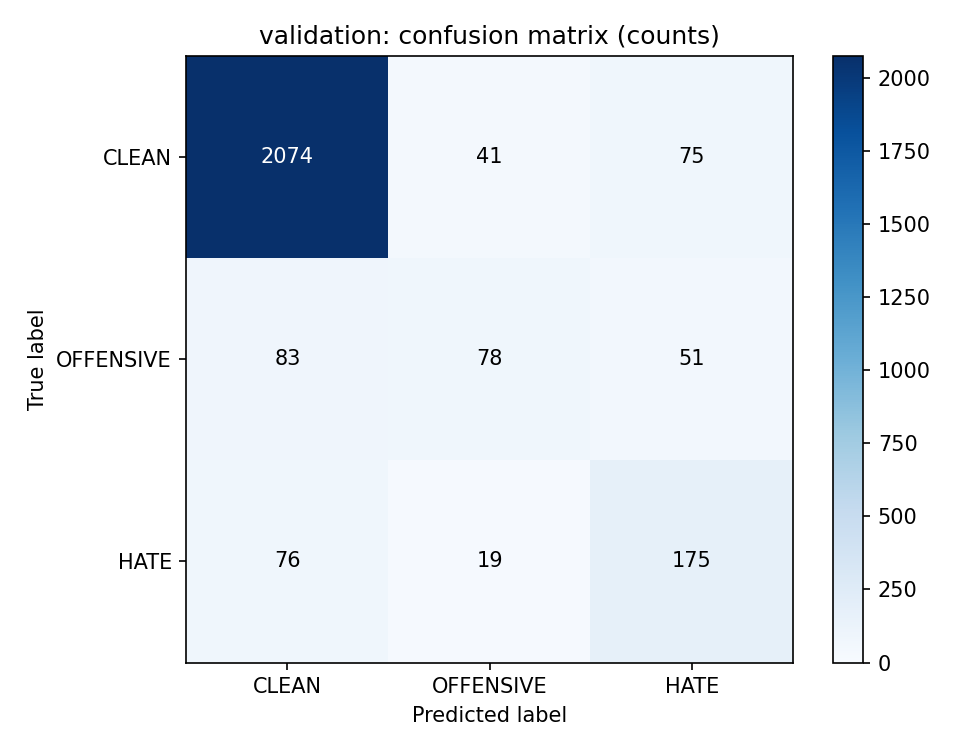

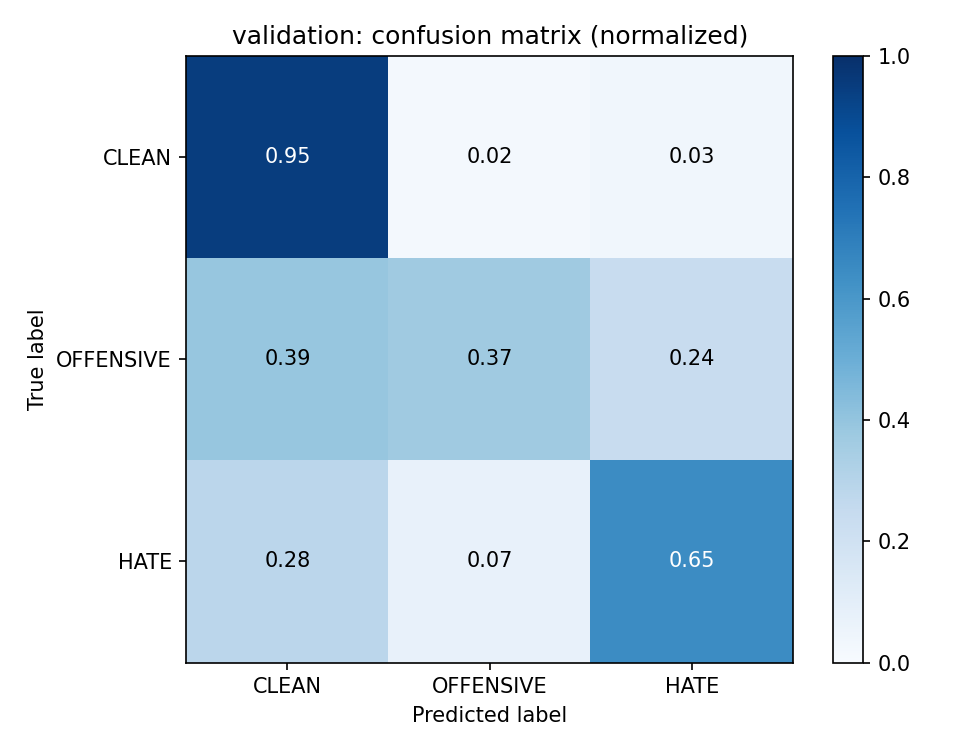

In [11]:
comparison = pd.read_csv(RUN / "comparison.csv") if selection else None
if comparison is not None:
    display(comparison)
    for candidate in selection["candidates"]:
        folder = RUN / candidate["family"]
        display(Markdown("### " + candidate["family"]))
        for name in ["train_metrics.json", "validation_metrics.json", "resources.json", "latency.json"]:
            if (folder / name).exists():
                print(name)
                display(read_json(folder / name))
        for name in ["learning_curve.csv", "training_history.csv"]:
            file = folder / name
            if file.exists() and file.stat().st_size > 1:
                print(name)
                display(pd.read_csv(file))
        for name in ["learning_curve.png", "training_history.png", "validation_reliability.png",
                     "validation_confusion_counts.png", "validation_confusion_normalized.png"]:
            if (folder / name).exists():
                display(Image(filename=str(folder / name)))
else:
    print("Chưa có train/dev metrics hoặc learning history của ViHSD.")

## 6. Policy ẩn và lựa chọn triển khai

Bảng ba lớp dùng argmax; policy ẩn dùng `p_harm = P(OFFENSIVE)+P(HATE) >= threshold`.
Không thêm argmax gate. Threshold chọn trên dev để tối đa binary F1, hòa thì ưu tiên
CLEAN FPR thấp rồi threshold cao. Precision khi không ẩn mẫu nào là không xác định (`null`).
Không dùng lại preset model cũ. Nếu đổi tiêu chí/FPR constraint, chốt trước test.

`validation_best_family` báo model đứng đầu dev. `selected_family` báo model triển khai:
BamiBERT theo cấu hình `deployment_family`, dù nó có thể không đứng đầu. Mỗi family có policy
riêng để báo cáo, extension phải dùng policy đúng BamiBERT artifact đã test.


Đứng đầu validation: phobert
Model triển khai đã chốt: bamibert


{'schema_version': 1,
 'policy_version': '1',
 'threshold': 0.2593429726077935,
 'comparison': '>=',
 'score_definition': 'P(OFFENSIVE)+P(HATE)',
 'labels': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'label_mapping': {'0': 'CLEAN', '1': 'OFFENSIVE', '2': 'HATE'},
 'criterion': 'max_f1',
 'selection_split': 'validation',
 'model_revision': 'vihsd-002-bamibert',
 'validation_metrics': {'harmful_precision': 0.6867924528301886,
  'harmful_recall': 0.7551867219917012,
  'harmful_f1': 0.7193675889328063,
  'clean_fpr': 0.07579908675799087,
  'hate_recall': 0.8,
  'hide_rate': 0.19835329341317365,
  'true_positive': 364,
  'false_positive': 166,
  'false_negative': 118,
  'true_negative': 2024,
  'hidden_count': 530,
  'hidden_hate': 216,
  'support_harmful': 482,
  'support_clean': 2190,
  'support_hate': 270,
  'n_samples': 2672},
 'candidate_count': 2673,
 'tie_break': ['lowest_clean_fpr', 'largest_threshold']}

,threshold,harmful_precision,harmful_recall,harmful_f1,clean_fpr,hate_recall,hide_rate,true_positive,false_positive,false_negative,true_negative,hidden_count,hidden_hate,support_harmful,support_clean,support_hate,n_samples
0,0.003702,0.180389,1.000000,0.305644,1.000000,1.000000,1.000000,482,2190,0,0,2672,270,482,2190,270,2672
1,0.003710,0.180457,1.000000,0.305741,0.999543,1.000000,0.999626,482,2189,0,1,2671,270,482,2190,270,2672
2,0.003715,0.180524,1.000000,0.305838,0.999087,1.000000,0.999251,482,2188,0,2,2670,270,482,2190,270,2672
3,0.003718,0.180592,1.000000,0.305935,0.998630,1.000000,0.998877,482,2187,0,3,2669,270,482,2190,270,2672
4,0.003723,0.180660,1.000000,0.306032,0.998174,1.000000,0.998503,482,2186,0,4,2668,270,482,2190,270,2672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2668,0.994712,0.750000,0.006224,0.012346,0.000457,0.007407,0.001497,3,1,479,2189,4,2,482,2190,270,2672
2669,0.994738,0.666667,0.004149,0.008247,0.000457,0.003704,0.001123,2,1,480,2189,3,1,482,2190,270,2672
2670,0.995004,1.000000,0.004149,0.008264,0.000000,0.003704,0.000749,2,0,480,2190,2,1,482,2190,270,2672
2671,0.995066,1.000000,0.002075,0.004141,0.000000,0.003704,0.000374,1,0,481,2190,1,1,482,2190,270,2672


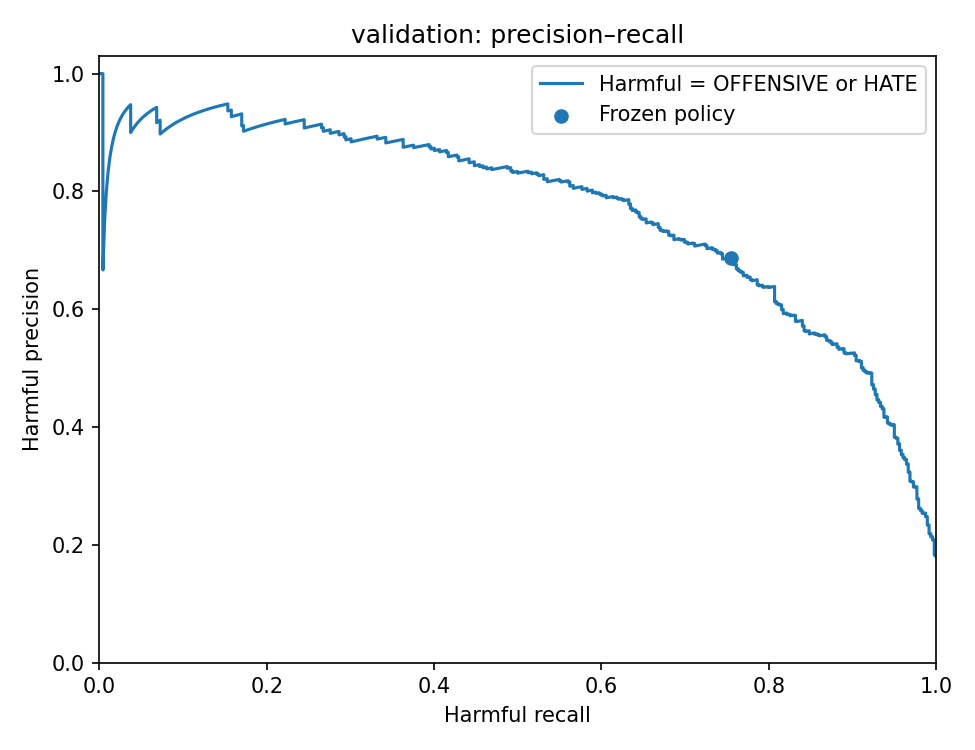

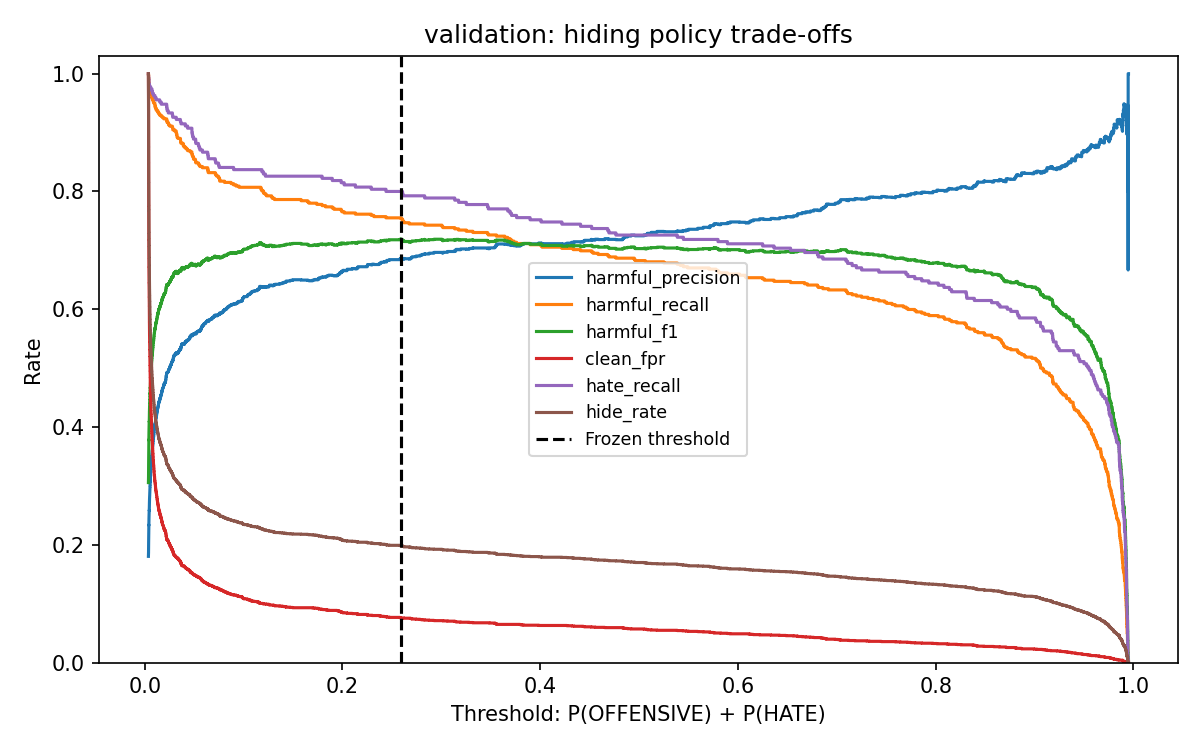

In [12]:
release = None
policy = None
if selection:
    print("Đứng đầu validation:", selection.get("validation_best_family", "run cũ chưa ghi riêng"))
    print("Model triển khai đã chốt:", selection["selected_family"])
    chosen = next(c for c in selection["candidates"] if c["family"] == selection["selected_family"])
    release = RUN_ROOT / chosen["artifact_dir"]
    policy = read_json(release / "decision_policy.json")
    display(policy)
    folder = RUN / chosen["family"]
    display(pd.read_csv(folder / "validation_threshold_sweep.csv"))
    for name in ["validation_precision_recall.png", "validation_threshold_sweep.png"]:
        if (folder / name).exists():
            display(Image(filename=str(folder / name)))
else:
    print("Chưa có threshold được chọn bằng dev hoặc release đã khóa.")

## 7. Khóa trước test

`selection.json` khóa finalist, model triển khai, checksum model/tokenizer/policy và fingerprint.
Transformer lưu model/tokenizer cùng preprocessing; baseline lưu pipeline. `metadata.json`
ghi source/library versions và phần cứng. Kiểm tra round-trip serialization trước test.
Thay artifact/config/dữ liệu sau khóa sẽ bị từ chối. Chỉ chạy final test sau khi đã đọc
các lựa chọn; không xóa test marker để tiếp tục tìm model tốt hơn.


In [13]:
if selection:
    display(selection)
    print("Release triển khai:", release)
    print("Số finalist:", len(selection["candidates"]))
else:
    print("Chưa khóa lựa chọn; không mở test.")

{'schema_version': 1,
 'run_id': 'vihsd-002',
 'locked_at': '2026-09-23T05:13:51.683328+00:00',
 'dataset_fingerprint': '889c4b1060ecd50850781d8501eaf6fc1b72d7f663c7dd10f6e14703ed5b7cc2',
 'synthetic': False,
 'selection_criterion': 'predeclared_deployment_family',
 'validation_best_family': 'phobert',
 'deployment_family': 'bamibert',
 'selected_family': 'bamibert',
 'model_revision': 'vihsd-002-bamibert',
 'candidates': [{'family': 'svm',
   'model_revision': 'vihsd-002-svm',
   'artifact_dir': 'artifacts/vihsd-002/svm',
   'sha256': {'pipeline.joblib': '2458567197ddd0f9f2c0122d22728710994dcf476577f4da30761d181665ebfd',
    'decision_policy.json': 'f728f46597e98c6c1f755d7e4f946f58d497c18b4922ead08ccdb2ef4483a24c'},
   'metadata_sha256': '96b7a1ef84cd923bda2701082ecb45f4280a4cf7e94385b622948dfbdf77fe74',
   'validation_macro_f1': 0.5954973362687008},
  {'family': 'logistic_regression',
   'model_revision': 'vihsd-002-logistic_regression',
   'artifact_dir': 'artifacts/vihsd-002/logist

Release triển khai: /content/drive/MyDrive/cs114-safeview/artifacts/vihsd-002/bamibert
Số finalist: 4


## 8. Final test và phân tích lỗi

Trong chế độ bổ sung, phần này chỉ đọc test lịch sử; phần 10 tự chạy test mới sau
train và khóa validation. Với workflow gốc, chỉ bật `RUN_FINAL_TEST=True` sau khóa;
các lần sau tắt cờ test và đọc báo cáo. Test đánh giá tất cả finalist
trên cùng split, không đổi model triển khai theo điểm test. Bootstrap intervals phản ánh
lấy mẫu test, không bao gồm bất định do seed/tuning.

Phiếu lỗi ở `RUN_ROOT/data/processed/<run>/<family>/<split>/error_review.csv`. Tra text theo
`sample_id` trong `bundle` cục bộ, không public raw text. Đọc khoảng 100 lỗi validation;
phân tích test sau khóa để viết báo cáo, không dùng để tune. Nhóm lỗi: chửi đùa, trích dẫn,
phủ định, mỉa mai, teencode/không dấu, cần ngữ cảnh, ranh giới OFFENSIVE/HATE.


In [ ]:
FINAL = RUN_ROOT / "results/final" / VIEW_RUN_ID if selection else None
if RUN_FINAL_TEST and not IMBALANCE_STUDY:
    assert selection and bundle is not None, "Cần bundle và selection đã khóa"
    evaluate_locked(bundle, RUN, RUN_ROOT)
final_metadata = read_json(FINAL / "metadata.json") if FINAL and (FINAL / "metadata.json").exists() else None
final_evaluated = bool(final_metadata and final_metadata.get("status") == "evaluated")
if final_evaluated:
    assert final_metadata.get("synthetic") is False, "Report test không rõ provenance"
    assert final_metadata.get("dataset_fingerprint") == selection["dataset_fingerprint"], "Report test khác dataset"
    assert final_metadata.get("selection_sha256") == sha256(RUN / "selection.json"), "Report test khác selection đã khóa"
    assert final_metadata.get("model_revision") == selection["model_revision"], "Report test khác release triển khai"
if final_evaluated:
    display(pd.read_csv(FINAL / "comparison.csv"))
    for candidate in selection["candidates"]:
        folder = FINAL / candidate["family"]
        display(Markdown("### " + candidate["family"]))
        display(read_json(folder / "test_metrics.json"))
        if (folder / "bootstrap.json").exists():
            display(read_json(folder / "bootstrap.json"))
        for name in ["test_confusion_counts.png", "test_confusion_normalized.png"]:
            if (folder / name).exists():
                display(Image(filename=str(folder / name)))
        print("Phiếu lỗi cục bộ:", RUN_ROOT / "data/processed" / VIEW_RUN_ID / candidate["family"] / "test/error_review.csv")
elif final_metadata:
    print("Test đã được truy cập nhưng report chưa hoàn tất. Giữ marker; sửa lỗi, không tune thêm.")
    display(final_metadata)
else:
    print("Chưa chạy test thật; chưa có kết luận chất lượng ViHSD.")

## 9. Chuẩn bị BamiBERT cho Hugging Face và SafeView

Làm theo [hướng dẫn từng bước](https://github.com/andrewthongle/cs114-ml-project/blob/main/docs/train-deploy-guide.md)
để publish, kiểm tra API và build extension sau khi hoàn thành notebook.

Model Hub lưu checkpoint/tokenizer/policy; Gradio Space chạy API. Sau test thật có thể bật
`RUN_PREPARE_BUNDLE` để tạo bundle local, chưa upload. Script kiểm tra provenance, source,
runtime, checksums và kết quả final. Bundle không có raw dataset/predictions từng mẫu.

Tự publish theo `scripts/templates/hf_space/README.md` sau khi review model card, điều kiện dữ liệu,
tài khoản và repo đích. Không nhúng token vào notebook hoặc extension. Space phải trả
`/classify` map phẳng `CLEAN/OFFENSIVE/HATE` qua POST+SSE; `/decision` chứa thêm policy/revision.
Extension dùng đúng threshold, cache/version và URL của BamiBERT artifact đã test.

Tài liệu HF hiện yêu cầu gói trả phí để tạo Space Gradio/Docker thông thường; CPU Basic
2 vCPU/16 GB không tính tiền compute theo giờ, PRO 9 USD/tháng. ZeroGPU miễn phí có điều kiện
và quota/hàng đợi. Kiểm tra chính sách lúc deploy: [Spaces](https://huggingface.co/docs/hub/spaces-overview),
[pricing](https://huggingface.co/pricing), [ZeroGPU](https://huggingface.co/docs/hub/spaces-zerogpu).
Không coi Colab Free/Space là cam kết API luôn sẵn sàng.


In [ ]:
BUNDLE = RUN_ROOT / "deploy/bundles" / RUN_ID if RUN_ID else None
if RUN_PREPARE_BUNDLE and not IMBALANCE_STUDY:
    assert selection and final_evaluated and release is not None, "Cần release và final test thật"
    assert selection["selected_family"] == "bamibert", "Notebook này chuẩn bị BamiBERT theo mục tiêu triển khai"
    subprocess.run([sys.executable, str(ROOT / "scripts/publish_hf.py"),
                    "--release-dir", str(release), "--evaluation-dir", str(FINAL),
                    "--output-dir", str(BUNDLE)], check=True, cwd=ROOT)
    print("Bundle local để review:", BUNDLE)
else:
    print("Chưa chuẩn bị/publish bundle. Mọi cờ hành động mặc định tắt.")

if selection and final_evaluated:
    print("Đã có báo cáo test tại:", FINAL)
    print("Đứng đầu dev:", selection.get("validation_best_family", "chưa ghi riêng"))
    print("Mục tiêu triển khai:", selection["selected_family"])
    print("Cần hoàn tất đọc lỗi, đo Space/extension và cập nhật Word/slide trước khi nộp.")
else:
    print("Chưa có thực nghiệm hoàn tất. Không tạo điểm số hoặc kết luận hơn/kém PhoBERT.")

## 10. Thực nghiệm mất cân bằng: kế hoạch, train và bảng đối chiếu

Kế hoạch lấy cấu hình **đã khóa của run tham chiếu**, không lấy các thay đổi YAML mới
để gọi chúng là thí nghiệm chỉ đổi trọng số. Trọng số Transformer = `n_train/(3*n_class)`;
SVM/LR dùng `class_weight="balanced"` trong từng lần fit, kể cả fold calibration.
Không oversample đồng thời. Ngưỡng ẩn chọn lại trên validation cho từng artifact.

Giữ sáu run mới và dữ liệu cũ trong cùng output root. Kế hoạch được ghi trước train,
không ghi đè khi chạy lại. Chạy tiếp một family khác bằng `IMBALANCE_FAMILIES`; không
đổi protocol để cải thiện theo test. Kết quả cũ thiếu hoặc bị sửa sẽ được báo lỗi.
Chế độ đọc chỉ hiển thị dữ liệu đã lưu, không tạo kế hoạch hoặc ghi báo cáo mới.

In [ ]:
from safeview_ml.imbalance import (
    prepare_imbalance_study, train_imbalance_study,
    evaluate_imbalance_study, export_imbalance_comparison,
)

if IMBALANCE_STUDY:
    if STUDY_TRAIN:
        assert bundle is not None, "Bật RUN_LOAD_DATA ở cell 1 trước khi train"
        assert not bundle.manifest.get("synthetic", False), "Không dùng fixture làm kết quả ViHSD"
        STUDY = prepare_imbalance_study(RUN_ROOT, REFERENCE_RUN_ID, RUN_ID)
        train_imbalance_study(bundle, STUDY, families=IMBALANCE_FAMILIES,
                              resume=RESUME_TRAINING)
    if STUDY_TEST:
        assert bundle is not None, "Bật RUN_LOAD_DATA trước khi đánh giá"
        assert STUDY and (STUDY / "protocol.json").exists(), "Train đợt mới trước khi đánh giá test"
        evaluate_imbalance_study(bundle, STUDY)
    if STUDY and (STUDY / "protocol.json").exists():
        display(read_json(STUDY / "protocol.json"))
        study_comparison = export_imbalance_comparison(
            STUDY, write=(os.getenv("SAFEVIEW_NOTEBOOK_READ_ONLY") != "1" and
                          (STUDY_TRAIN or STUDY_TEST))
        )
        compact_columns = ["family", "variant", "status", "validation_macro_f1", "test_macro_f1",
                           "validation_offensive_f1", "validation_hate_f1", "test_offensive_f1",
                           "test_hate_f1", "train_validation_gap_pp", "historical_environment_differences"]
        display(study_comparison[[c for c in compact_columns if c in study_comparison]])
        print("Bảng đầy đủ gồm precision/recall từng lớp, policy, tài nguyên:")
        display(study_comparison)
        if study_comparison.attrs.get("deltas"):
            display(Markdown("**Chênh lệch có trọng số − không trọng số (điểm phần trăm)**"))
            display(pd.DataFrame(study_comparison.attrs["deltas"]))
        if (STUDY / "study_selection.json").exists():
            display(Markdown("**Lựa chọn đã khóa bằng validation trước test bổ sung**"))
            display(read_json(STUDY / "study_selection.json"))
        print("Bảng đối chiếu:", STUDY)
    else:
        print("Chưa có đợt mới. Đặt RUN_ID khác run tham chiếu và bật RUN_TRAINING ở cell 1.")


### Bundle BamiBERT của đợt mới

`RUN_PREPARE_BUNDLE` chạy sau train/test trong cùng lượt Run All.
Model triển khai lấy từ lựa chọn BamiBERT đã khóa theo validation, không chọn theo test.
Nếu cấu hình lịch sử được chọn, xác minh và dùng lại bundle cũ; không đóng gói lại
artifact lịch sử bằng source mới. Bundle mới đã tồn tại cũng được xác minh trước khi
dùng lại. Chỉ tạo file local, không publish.

In [ ]:
if STUDY_BUNDLE:
    assert STUDY and (STUDY / "study_selection.json").exists(), "Hoàn tất train và khóa đánh giá trước bundle"
    deploy_choice = read_json(STUDY / "study_selection.json")["validation_best_by_family"]["bamibert"]
    deploy_run_id = deploy_choice["run_id"]
    deploy_final = RUN_ROOT / "results/final" / deploy_run_id
    assert (deploy_final / "metadata.json").exists() and read_json(deploy_final / "metadata.json").get("status") == "evaluated", "Cần test hoàn tất cho BamiBERT đã chọn"
    deploy_release = RUN_ROOT / "artifacts" / deploy_run_id / "bamibert"
    deploy_bundle = RUN_ROOT / "deploy/bundles" / deploy_run_id
    subprocess.run([sys.executable, str(ROOT / "scripts/publish_hf.py"),
                    "--release-dir", str(deploy_release), "--evaluation-dir", str(deploy_final),
                    "--output-dir", str(deploy_bundle),
                    "--reuse-only" if deploy_run_id == REFERENCE_RUN_ID else "--reuse-existing"],
                   check=True, cwd=ROOT)
    print("Bundle local để review:", deploy_bundle)


### Đọc curve, confusion matrix và lỗi của các run bổ sung

Đối chiếu OFFENSIVE→CLEAN, HATE→CLEAN và nhầm OFFENSIVE↔HATE; xem mức tăng recall
có đi kèm giảm precision hay không. Đọc phiếu lỗi validation trước khi mở test bổ sung.
Mỗi biểu đồ dưới đây ghi rõ run/cấu hình; kết quả Transformer loss thường nằm ở phần
lịch sử phía trên. Loss giữa hai cách tính không có cùng thang mục tiêu.

In [ ]:
if IMBALANCE_STUDY and STUDY and (STUDY / "protocol.json").exists():
    for entry in read_json(STUDY / "protocol.json")["runs"]:
        study_run = RUN_ROOT / "results/runs" / entry["run_id"]
        if not (study_run / "selection.json").exists():
            continue
        display(Markdown("### " + entry["family"] + " — " + entry["variant"]))
        print("Run:", entry["run_id"])
        for name in ["learning_curve.png", "training_history.png", "validation_confusion_normalized.png"]:
            plot = study_run / entry["family"] / name
            if plot.exists():
                display(Image(filename=str(plot)))
        print("Phiếu lỗi validation:", RUN_ROOT / "data/processed" / entry["run_id"] /
              entry["family"] / "validation/error_review.csv")
        study_final = RUN_ROOT / "results/final" / entry["run_id"]
        if (study_final / "metadata.json").exists() and read_json(study_final / "metadata.json").get("status") == "evaluated":
            plot = study_final / entry["family"] / "test_confusion_normalized.png"
            if plot.exists():
                display(Image(filename=str(plot)))


### Kết luận cần viết từ kết quả thật

- Model nào đạt Macro-F1/F1 từng lớp tốt nhất; BamiBERT đánh đổi gì so với PhoBERT và baseline?
- Khoảng cách train/dev, loss/learning curves và lỗi phổ biến cho thấy giới hạn nào?
- CLEAN bị ẩn nhầm bao nhiêu, HATE được ẩn bao nhiêu ở policy đã khóa?
- Artifact, RAM, CPU latency và API p50/p95 có phù hợp demo/extension không?
- Giới hạn miền dữ liệu, tiếng lóng/không dấu, routing/lexicon và độ sẵn sàng của Space?
- Trọng số lớp thay đổi Macro-F1, precision/recall OFFENSIVE/HATE và lỗi CLEAN như thế nào?
- So sánh lịch sử có khác môi trường/source không? Một seed và test đã xem giới hạn kết luận gì?

Không suy diễn chất lượng ngôn ngữ từ smoke test; không gọi model mới là tốt nhất nếu bảng
thực nghiệm không chứng minh. Word/slide cũ cần sửa cả phạm vi phương pháp lẫn số liệu.
